# GPR — Plotting

Loads artifacts produced by `GPR_calculation.ipynb` from `OUTPUT_FOLDER` and produces every figure. Tune any cell freely per sample size — the underlying fit is not re-run.


In [1]:
import  os
import  json
import  joblib
import  numpy as np
import  pandas as pd
import  thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, MLPreprocessing
from    thermoift import plot_correlation_heatmap


In [2]:
OUTPUT_FOLDER = "SLURM_GPR_residual_5000"


## Load calculation artifacts


In [3]:
meta = json.load(open(os.path.join(OUTPUT_FOLDER, "GPR_artifacts_meta.json")))
features = meta["features"]
target   = meta["target"]

gpr_model = joblib.load(os.path.join(OUTPUT_FOLDER, "GPR_residual_model.joblib"))
df        = pd.read_parquet(os.path.join(OUTPUT_FOLDER, "GPR_df_full.parquet"))

_splits = np.load(os.path.join(OUTPUT_FOLDER, "GPR_splits.npz"))
train_idx = _splits["train_idx"]
test_idx  = _splits["test_idx"]
val_idx   = _splits["val_idx"]

X_train = df.loc[train_idx, features]
X_test  = df.loc[test_idx,  features]
X_val   = df.loc[val_idx,   features]
y_train = df.loc[train_idx, target]
y_test  = df.loc[test_idx,  target]
y_val   = df.loc[val_idx,   target]

_preds = np.load(os.path.join(OUTPUT_FOLDER, "GPR_predictions.npz"))
y_train_pred, y_train_std = _preds["y_train_pred"], _preds["y_train_std"]
y_test_pred,  y_test_std  = _preds["y_test_pred"],  _preds["y_test_std"]
y_val_pred,   y_val_std   = _preds["y_val_pred"],   _preds["y_val_std"]

_recon = np.load(os.path.join(OUTPUT_FOLDER, "GPR_gamma_reconstructed.npz"))
gamma_cDFT_train = _recon["gamma_cDFT_train"]; gamma_pred_train = _recon["gamma_pred_train"]
gamma_cDFT_test  = _recon["gamma_cDFT_test"];  gamma_pred_test  = _recon["gamma_pred_test"]
gamma_cDFT_val   = _recon["gamma_cDFT_val"];   gamma_pred_val   = _recon["gamma_pred_val"]

_feature_importances = np.load(os.path.join(OUTPUT_FOLDER, "GPR_feature_importances.npy"))

print(f"Loaded artifacts from: {OUTPUT_FOLDER}")
print(f"Features: {features}")
print(f"train / test / val sizes: {len(train_idx)} / {len(test_idx)} / {len(val_idx)}")


Loaded artifacts from: SLURM_GPR_residual_5000
Features: ['T', 'P', 'z_argon', 'z_carbon_dioxide', 'z_carbon_monoxide', 'z_hydrogen', 'z_hydrogen_sulfide', 'z_methane', 'z_nitrogen']
train / test / val sizes: 3500 / 750 / 750


In [4]:
post = MLPostprocessing(
    y_true              = y_test,
    y_pred              = y_test_pred,
    target              = "delta_gamma",
    feature_importances = _feature_importances,
    feature_names       = features,
    datasets            = {
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)


## EDA on residual


Feature correlations with residual:
T                     0.531983
z_carbon_dioxide      0.293321
z_hydrogen_sulfide    0.026659
z_carbon_monoxide     0.003195
z_methane            -0.028436
P                    -0.062274
z_argon              -0.099832
z_nitrogen           -0.179178
z_hydrogen           -0.179656
Name: residual, dtype: float64


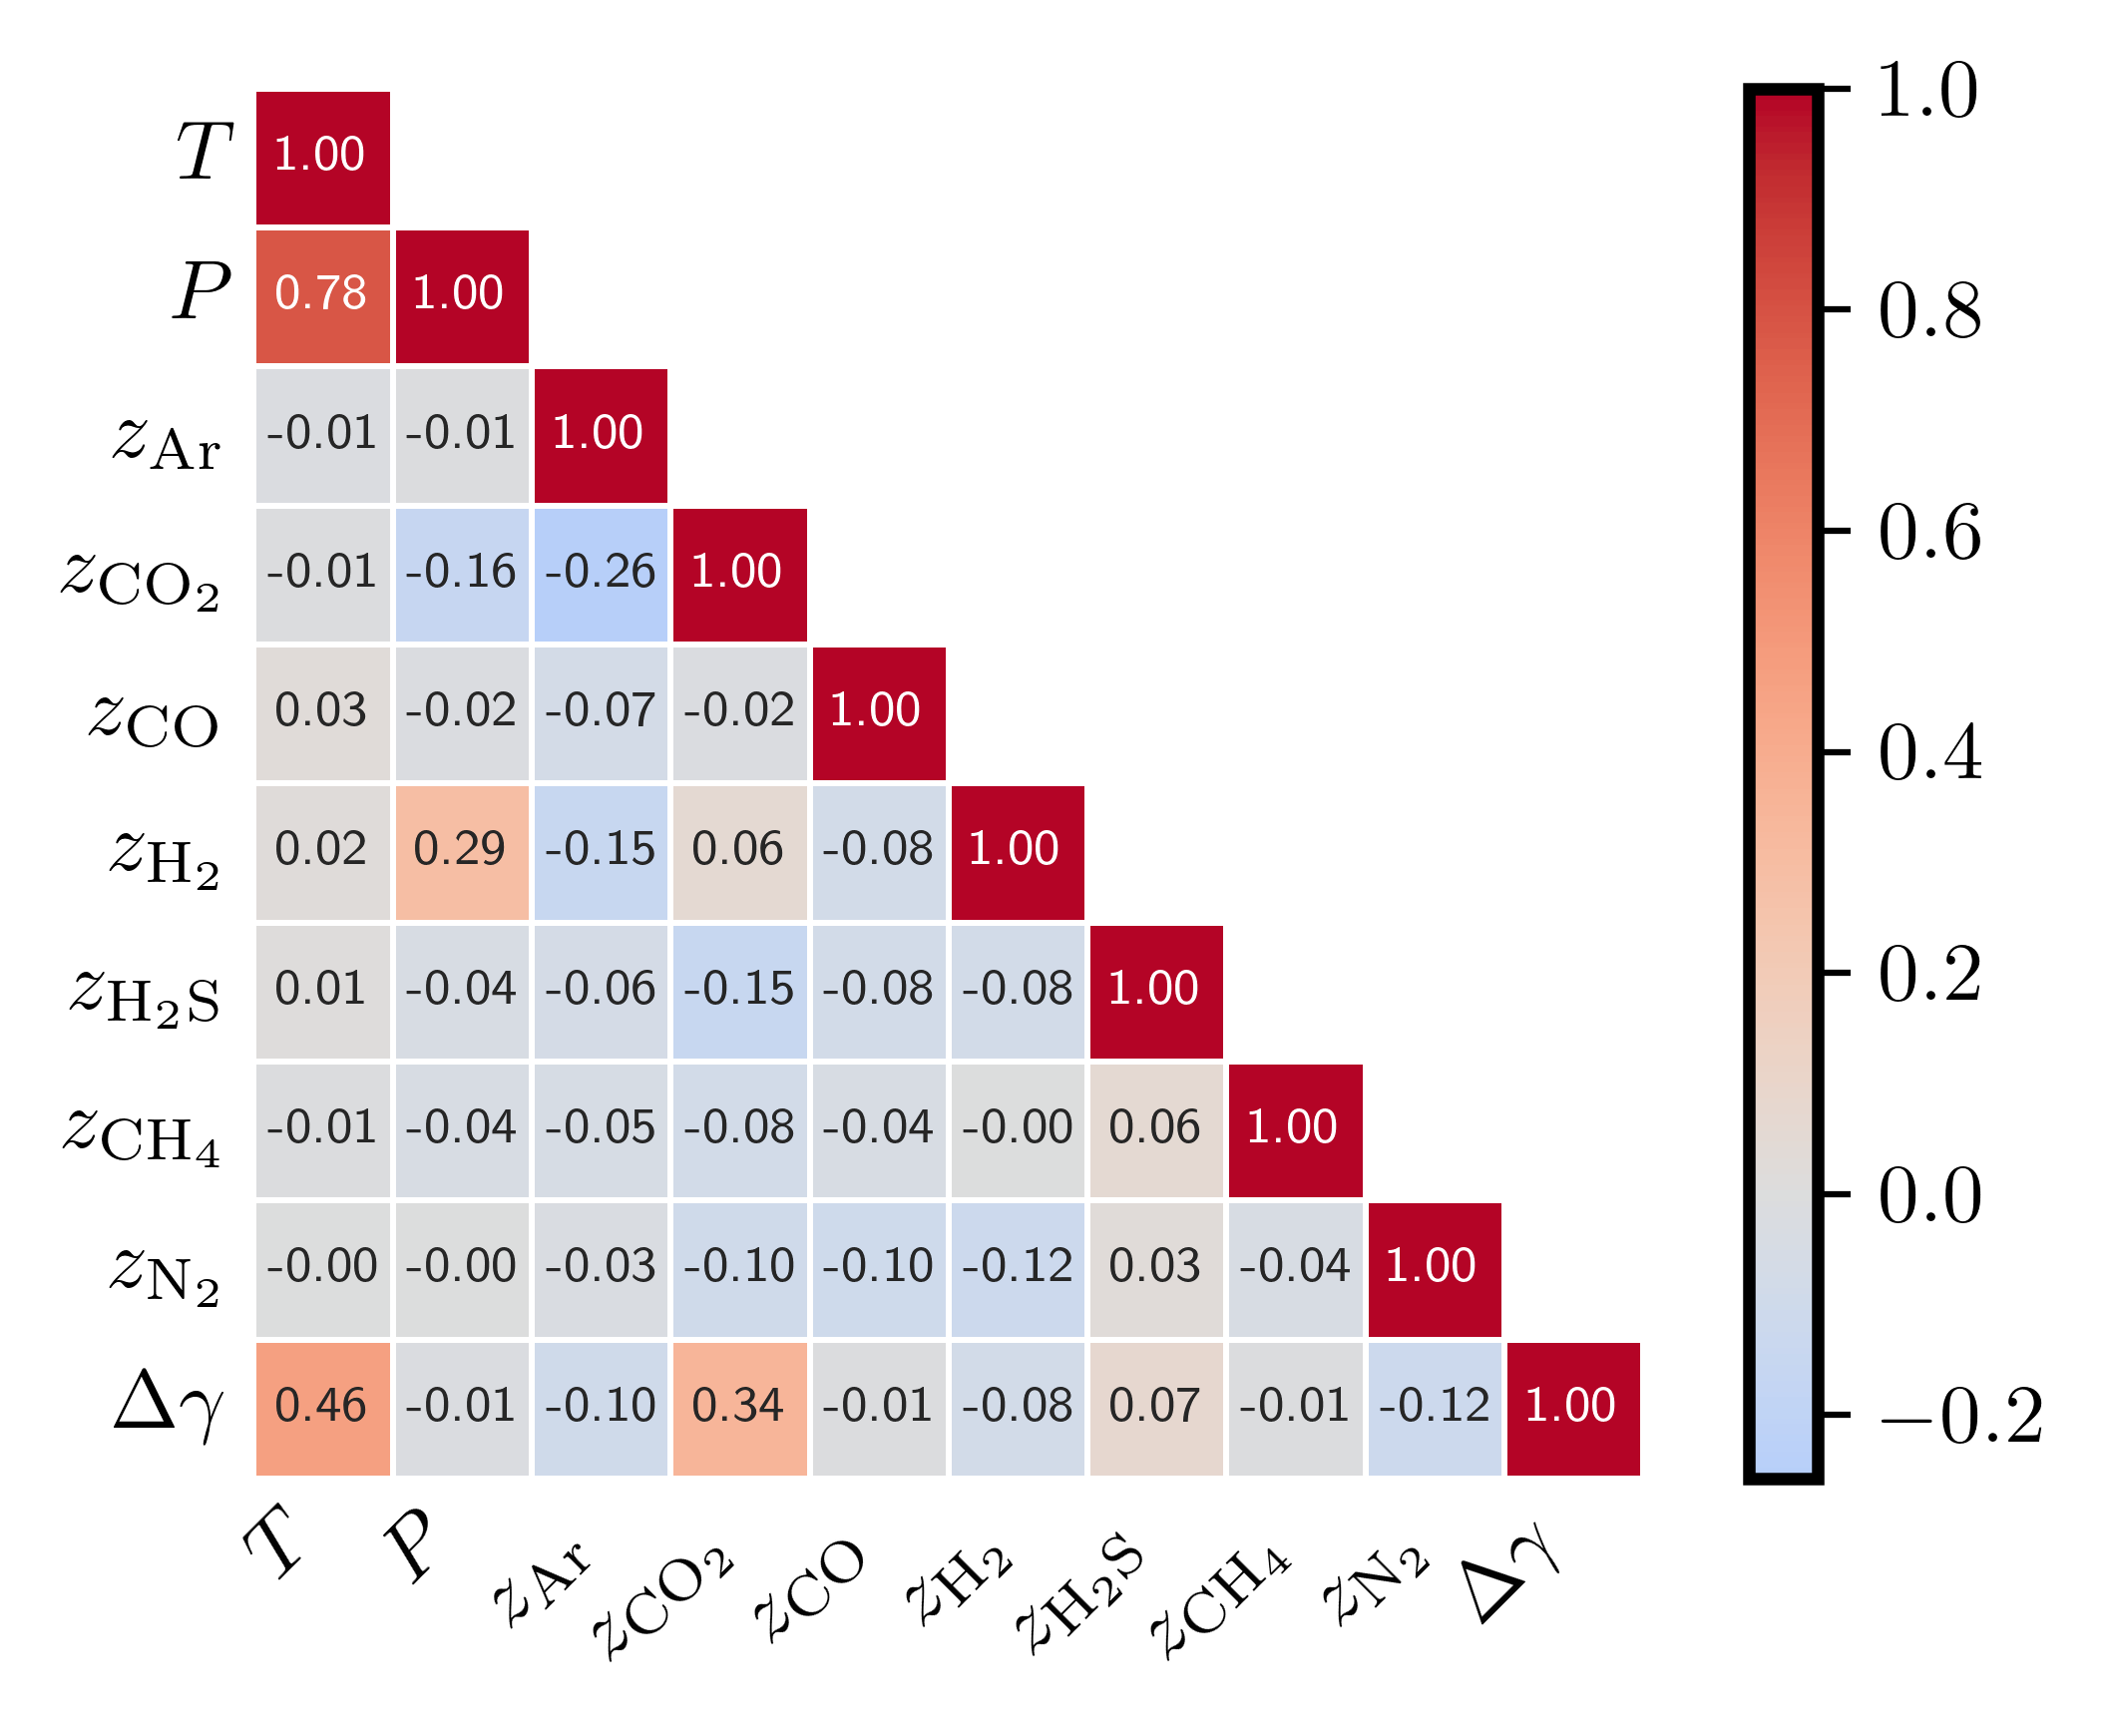

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [5]:
plot_correlation_heatmap(df, features, target, save_path="GPR_residual_correlation", folder=OUTPUT_FOLDER)

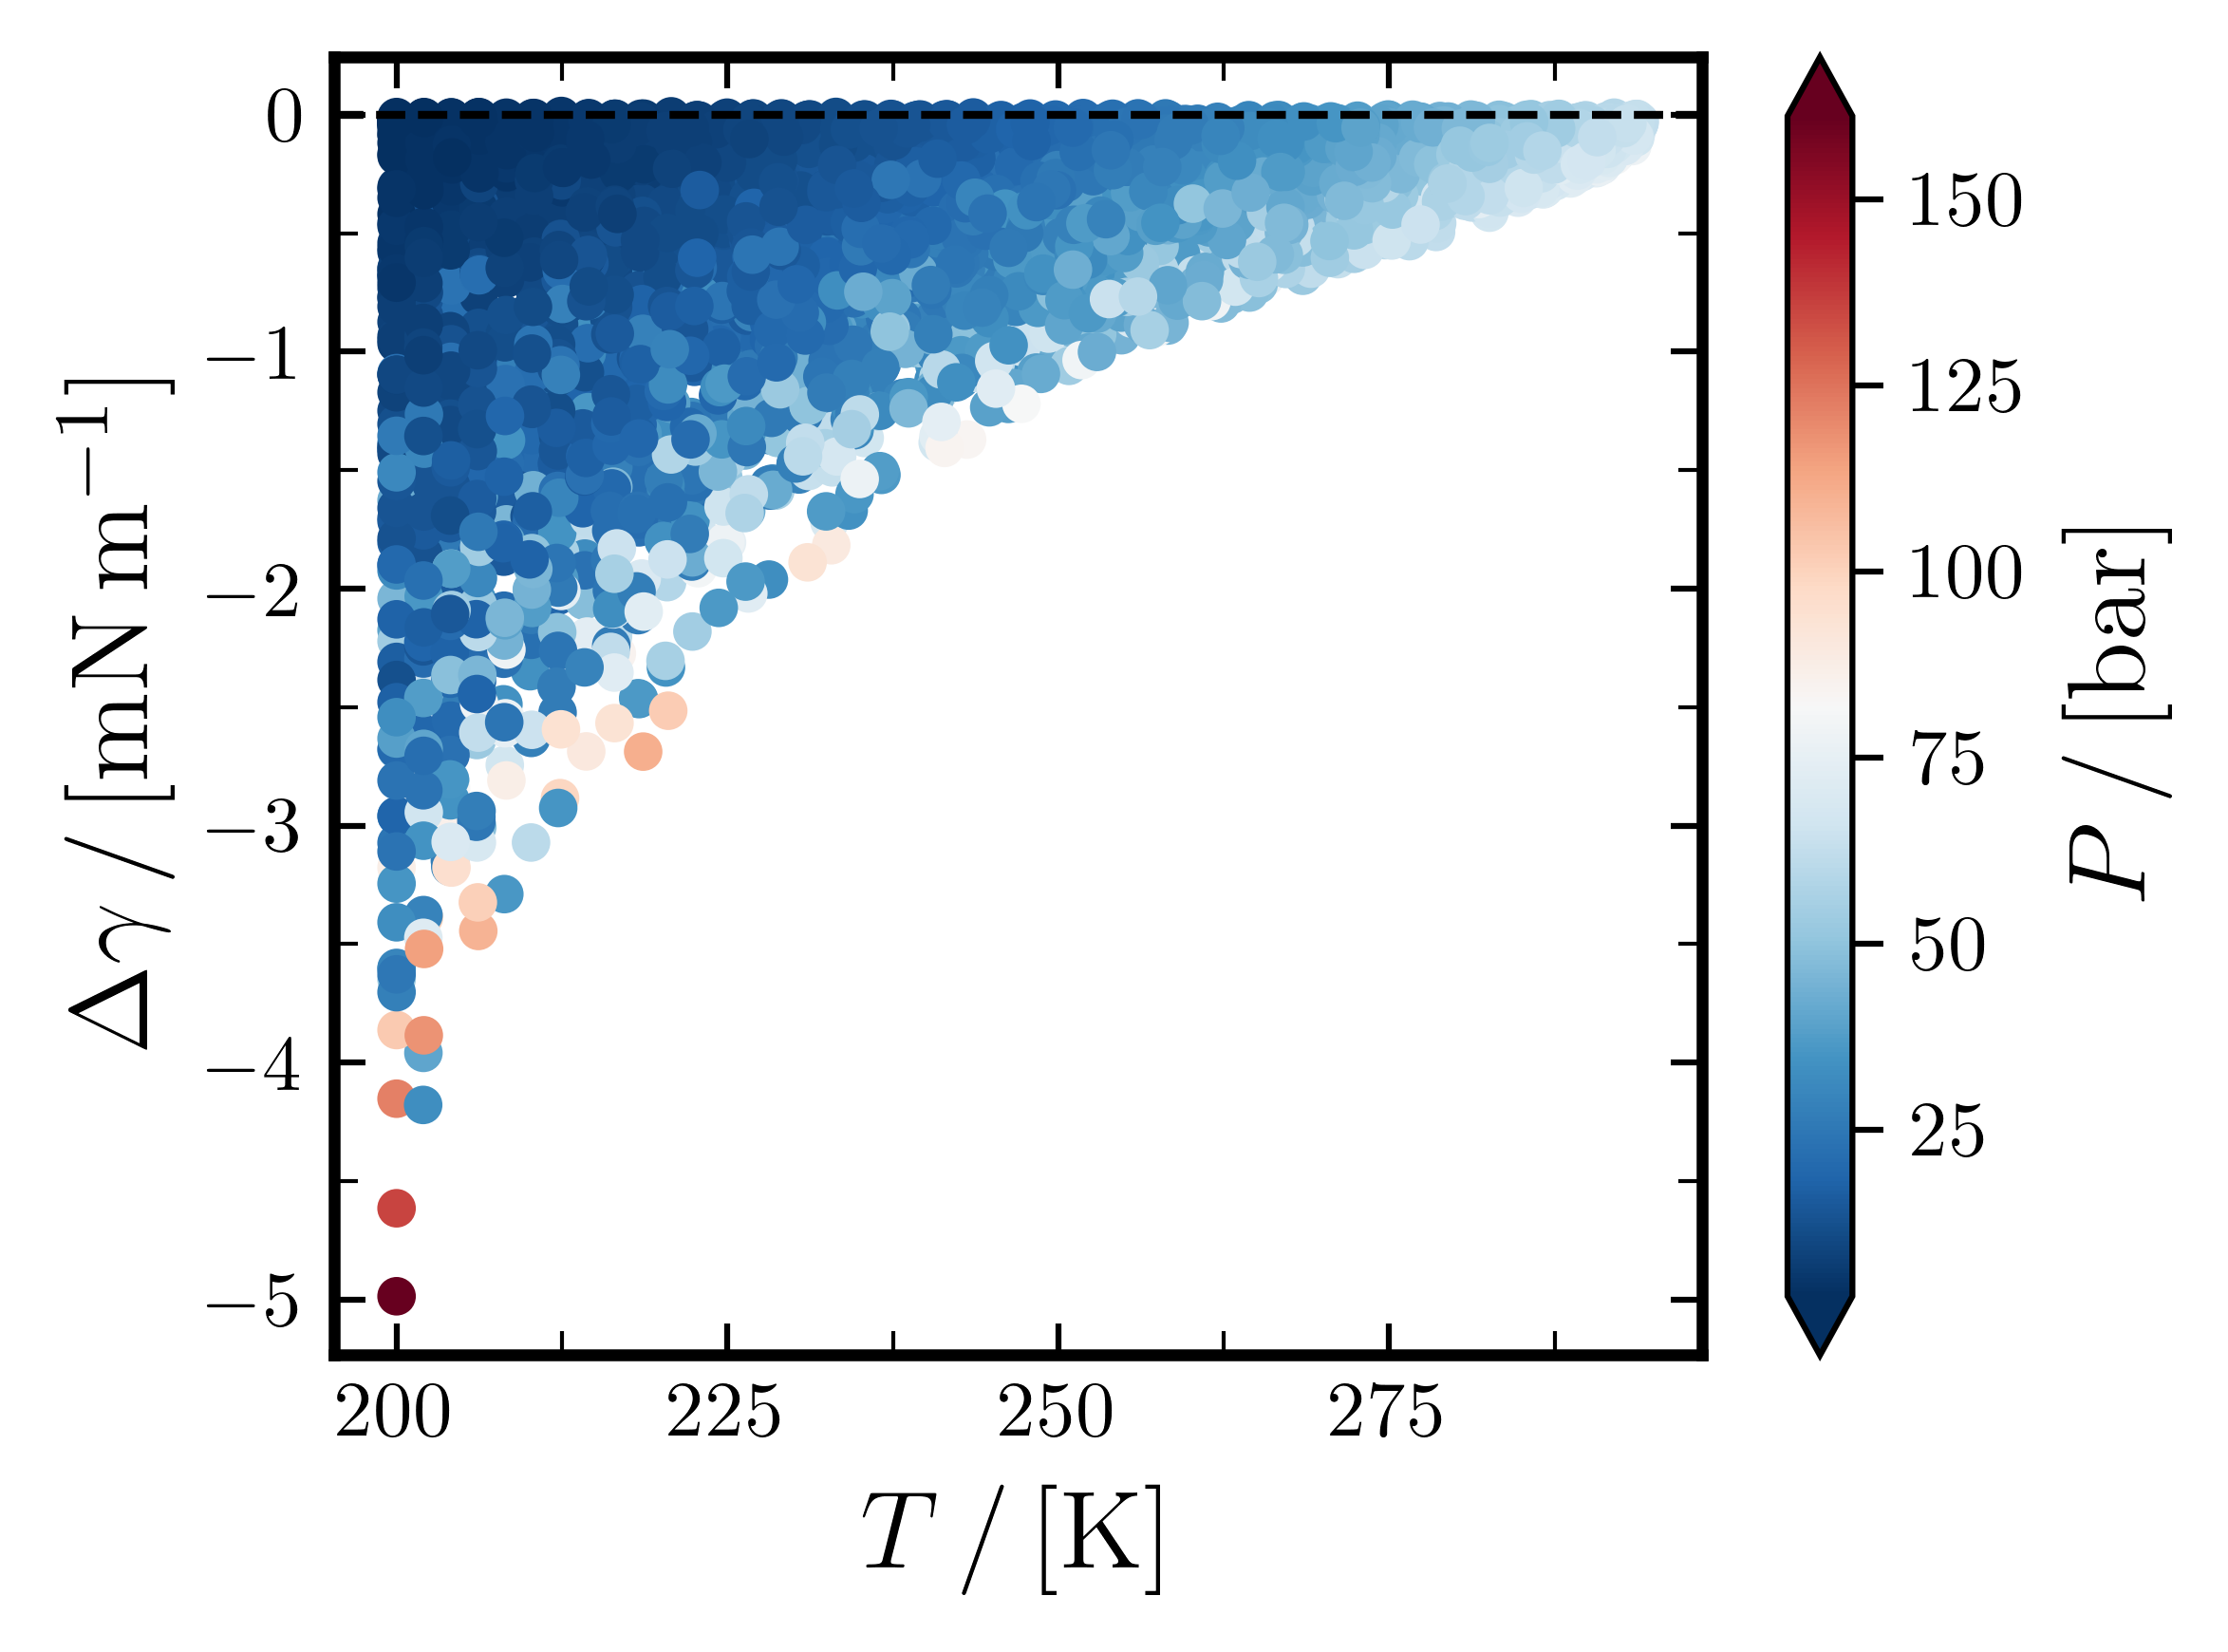

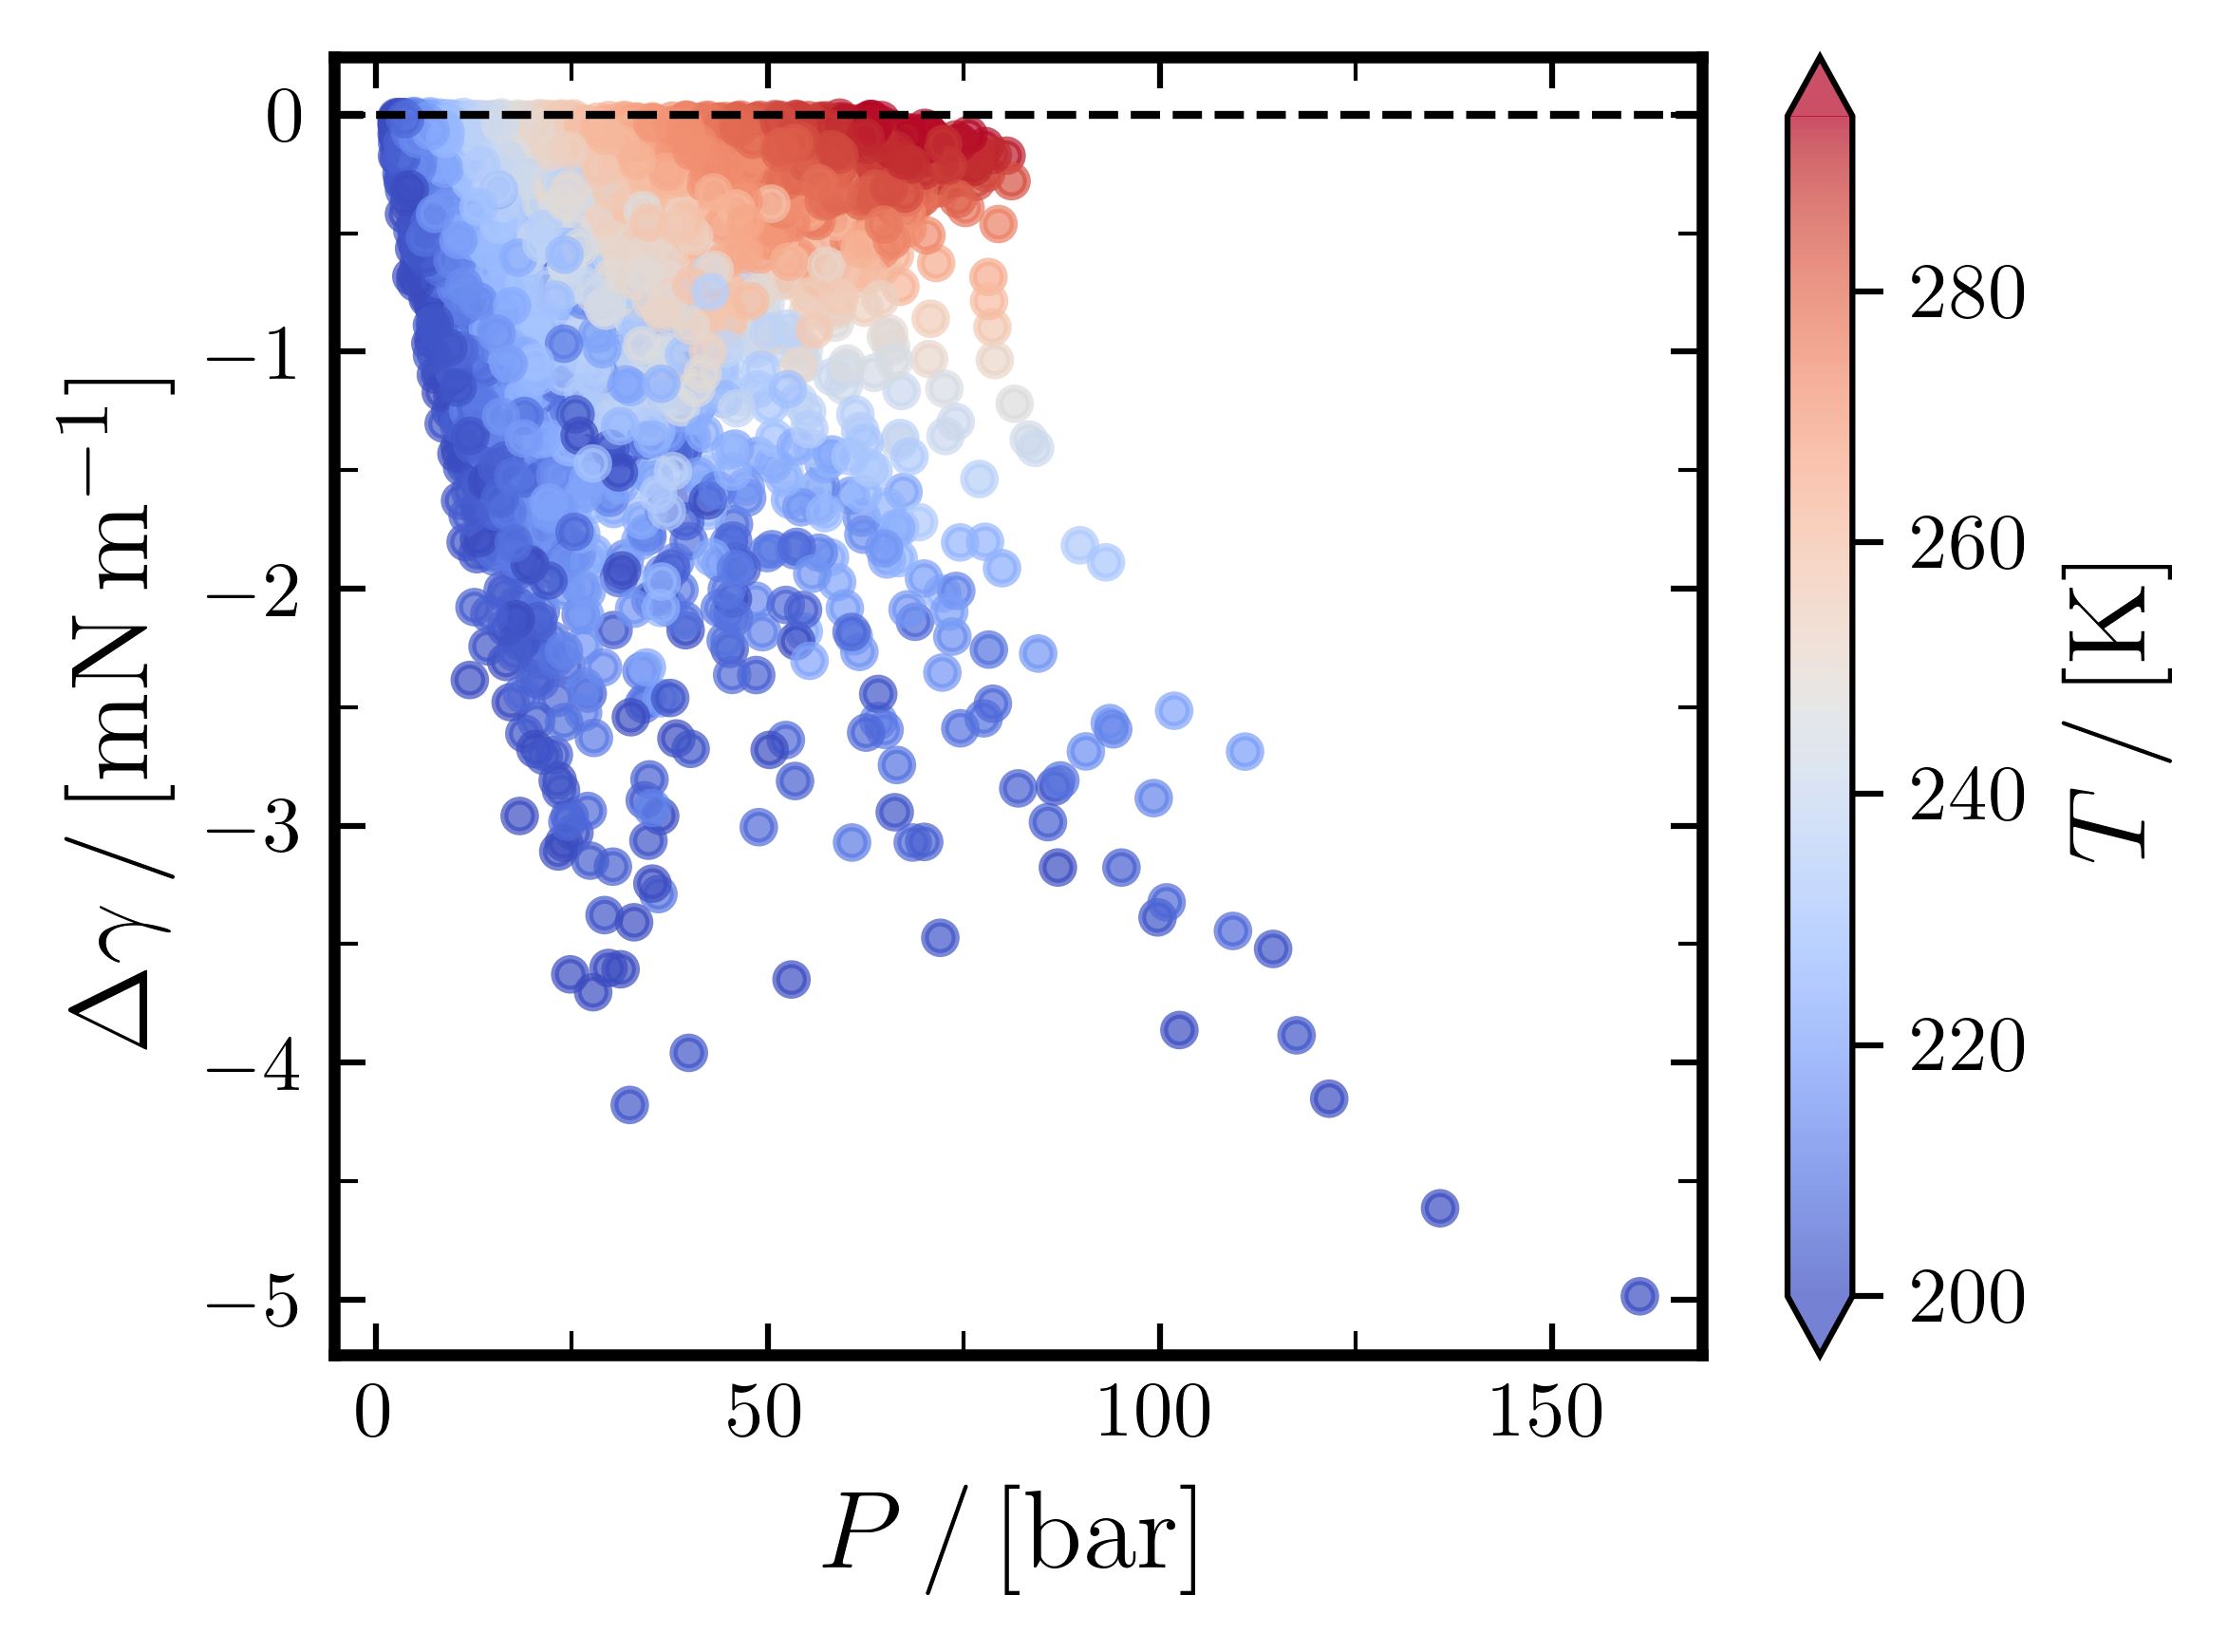

(<Figure size 2400x1800 with 2 Axes>,
 <Axes: xlabel='$P \\, / \\, [\\mathrm{bar}]$', ylabel='$\\Delta \\gamma \\, / \\, [\\mathrm{mN} \\, \\mathrm{m}^{-1}]$'>)

In [6]:
prep = MLPreprocessing(df=df, features=features, target=target)

prep.plot_scatter(
    x           = "T",
    y           = target,
    color_by    = "P",
    hline       = 0.0,
    cmap        = "RdBu_r",   # match panel (a) (plot_2d_response_surface)
    alpha       = 1,       # full saturation to match panel (a) brightness
    save_path   = "GPR_residual_vs_T",
    folder      = OUTPUT_FOLDER,
)

prep.plot_scatter(
    x           = "P",
    y           = target,
    color_by    = "T",
    hline       = 0.0,
    save_path   = "GPR_residual_vs_P",
    folder      = OUTPUT_FOLDER,
)

## Residual-model diagnostics


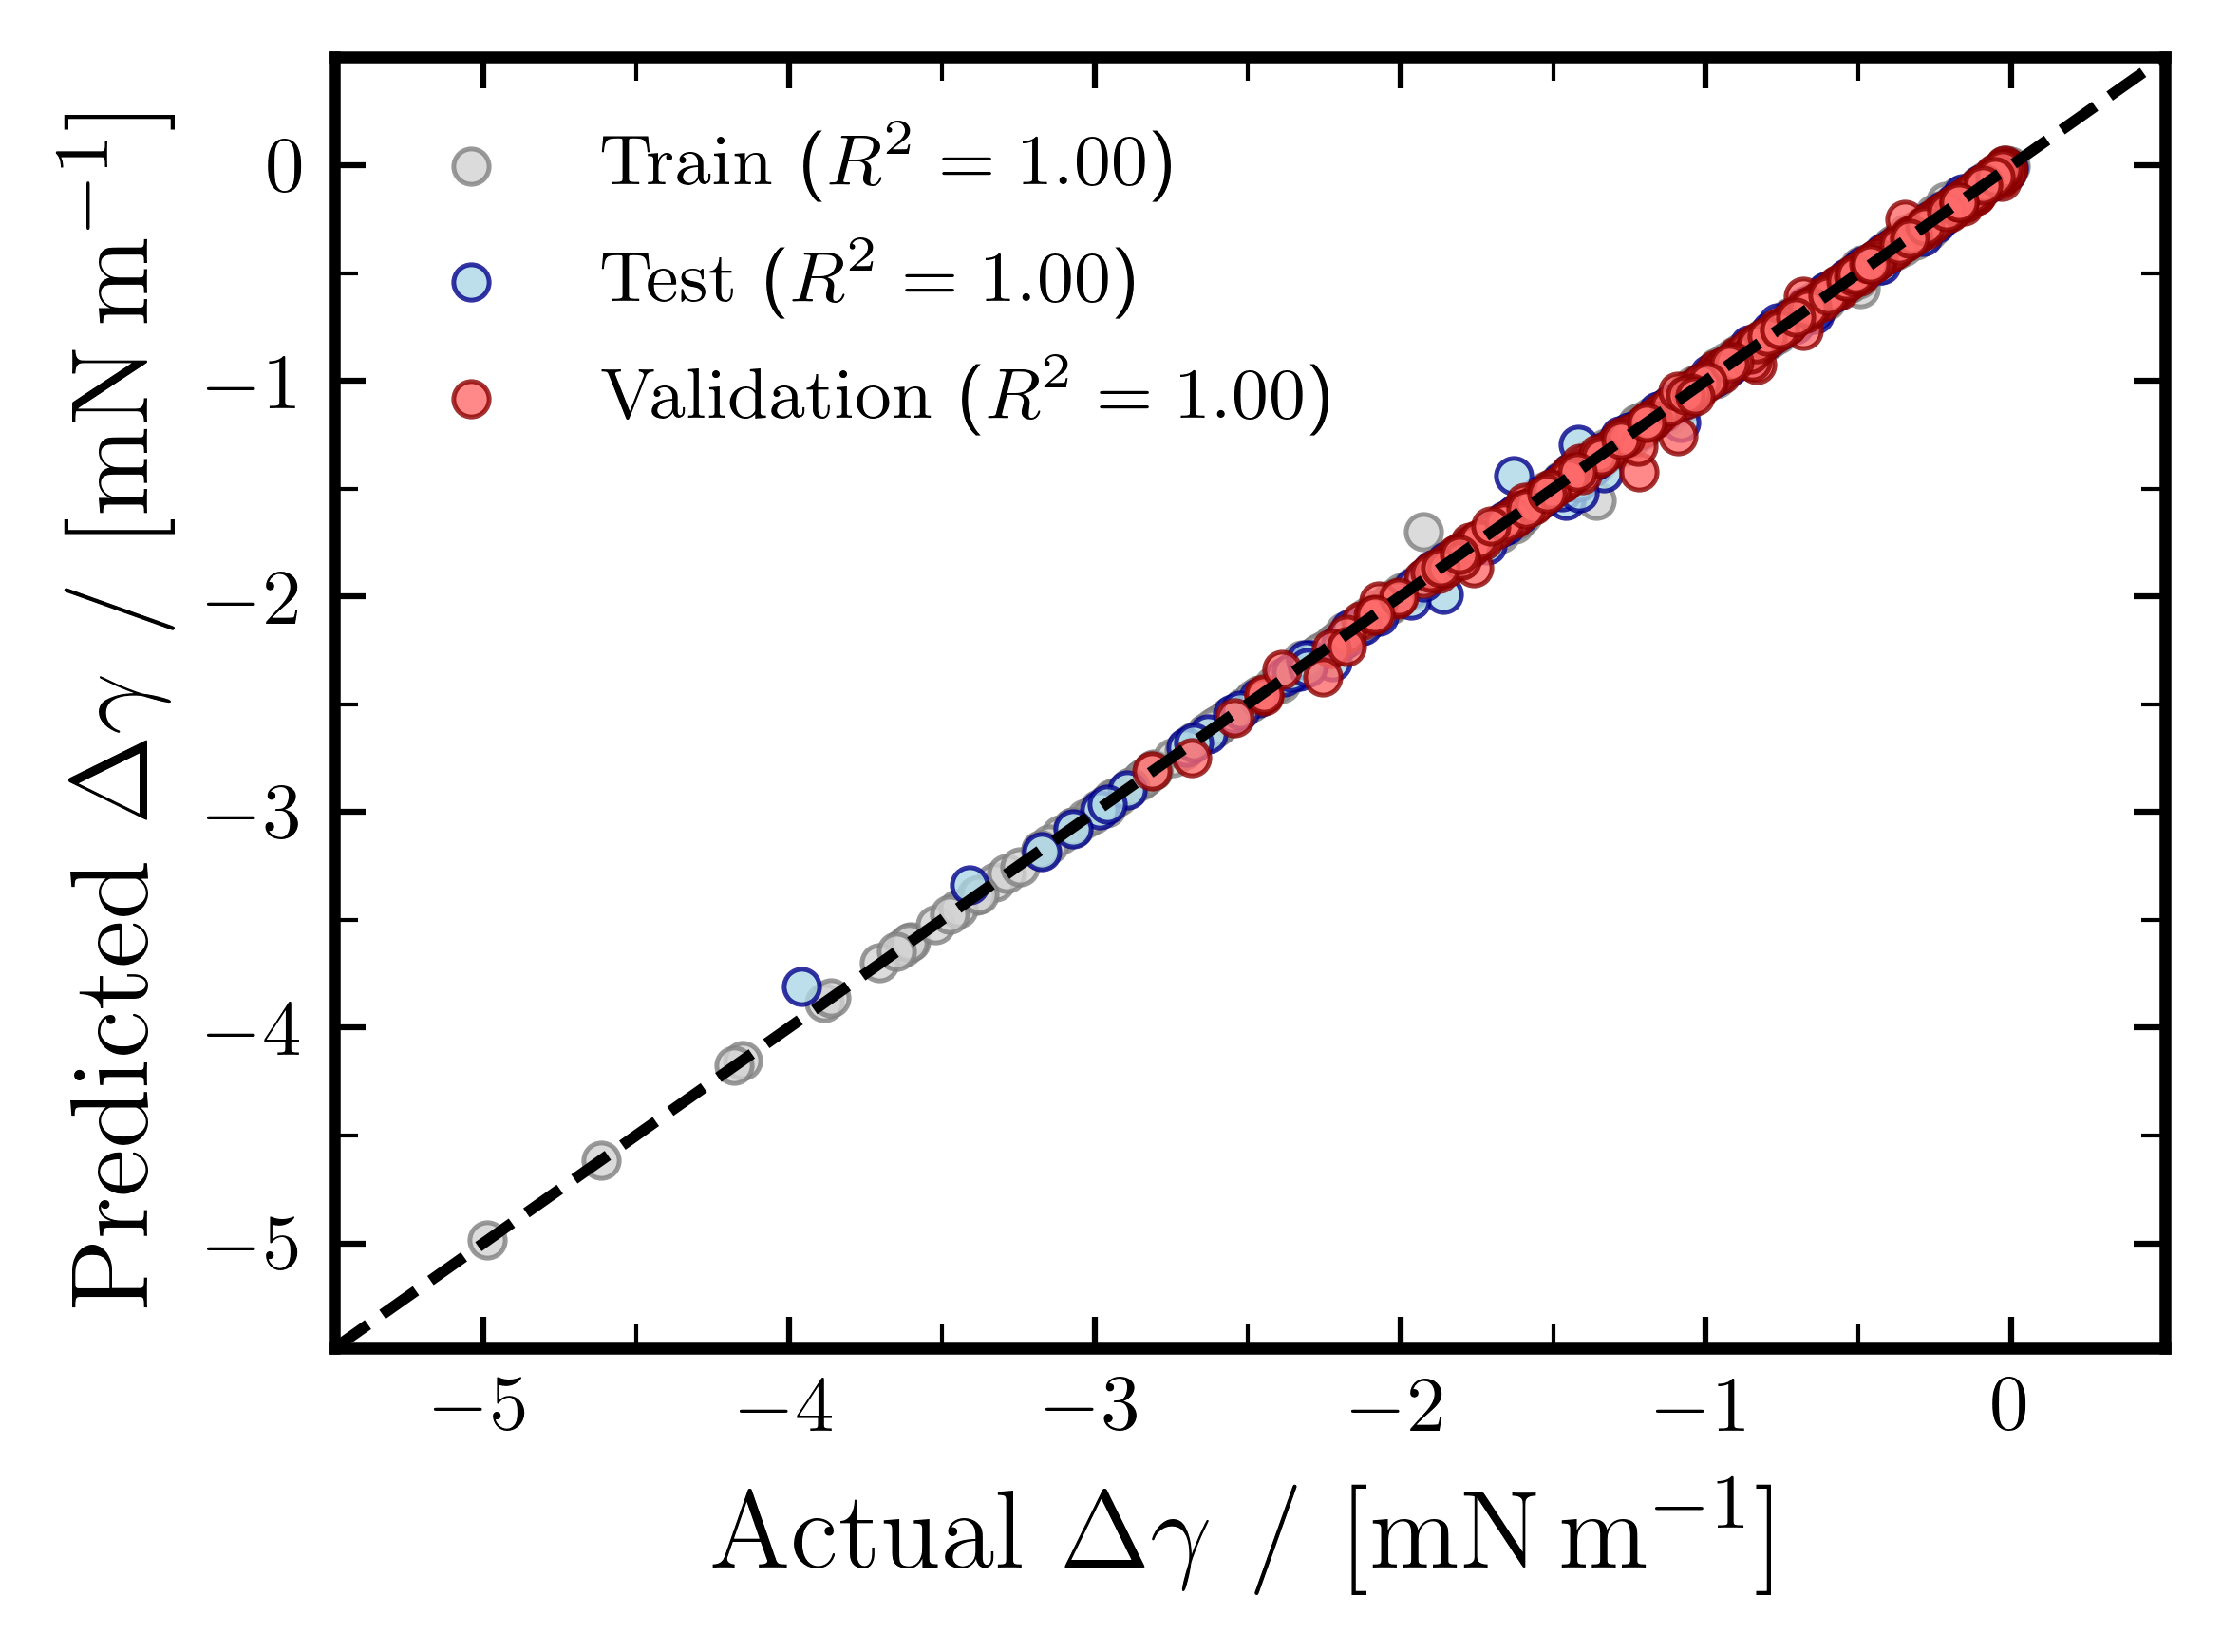

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}$ $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$\\mathrm{Predicted}$ $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [7]:
# Parity plot
post.plot_parity(model_name="GPR (RBF)", save_path="GPR_gamma_parity_plot", folder=OUTPUT_FOLDER)

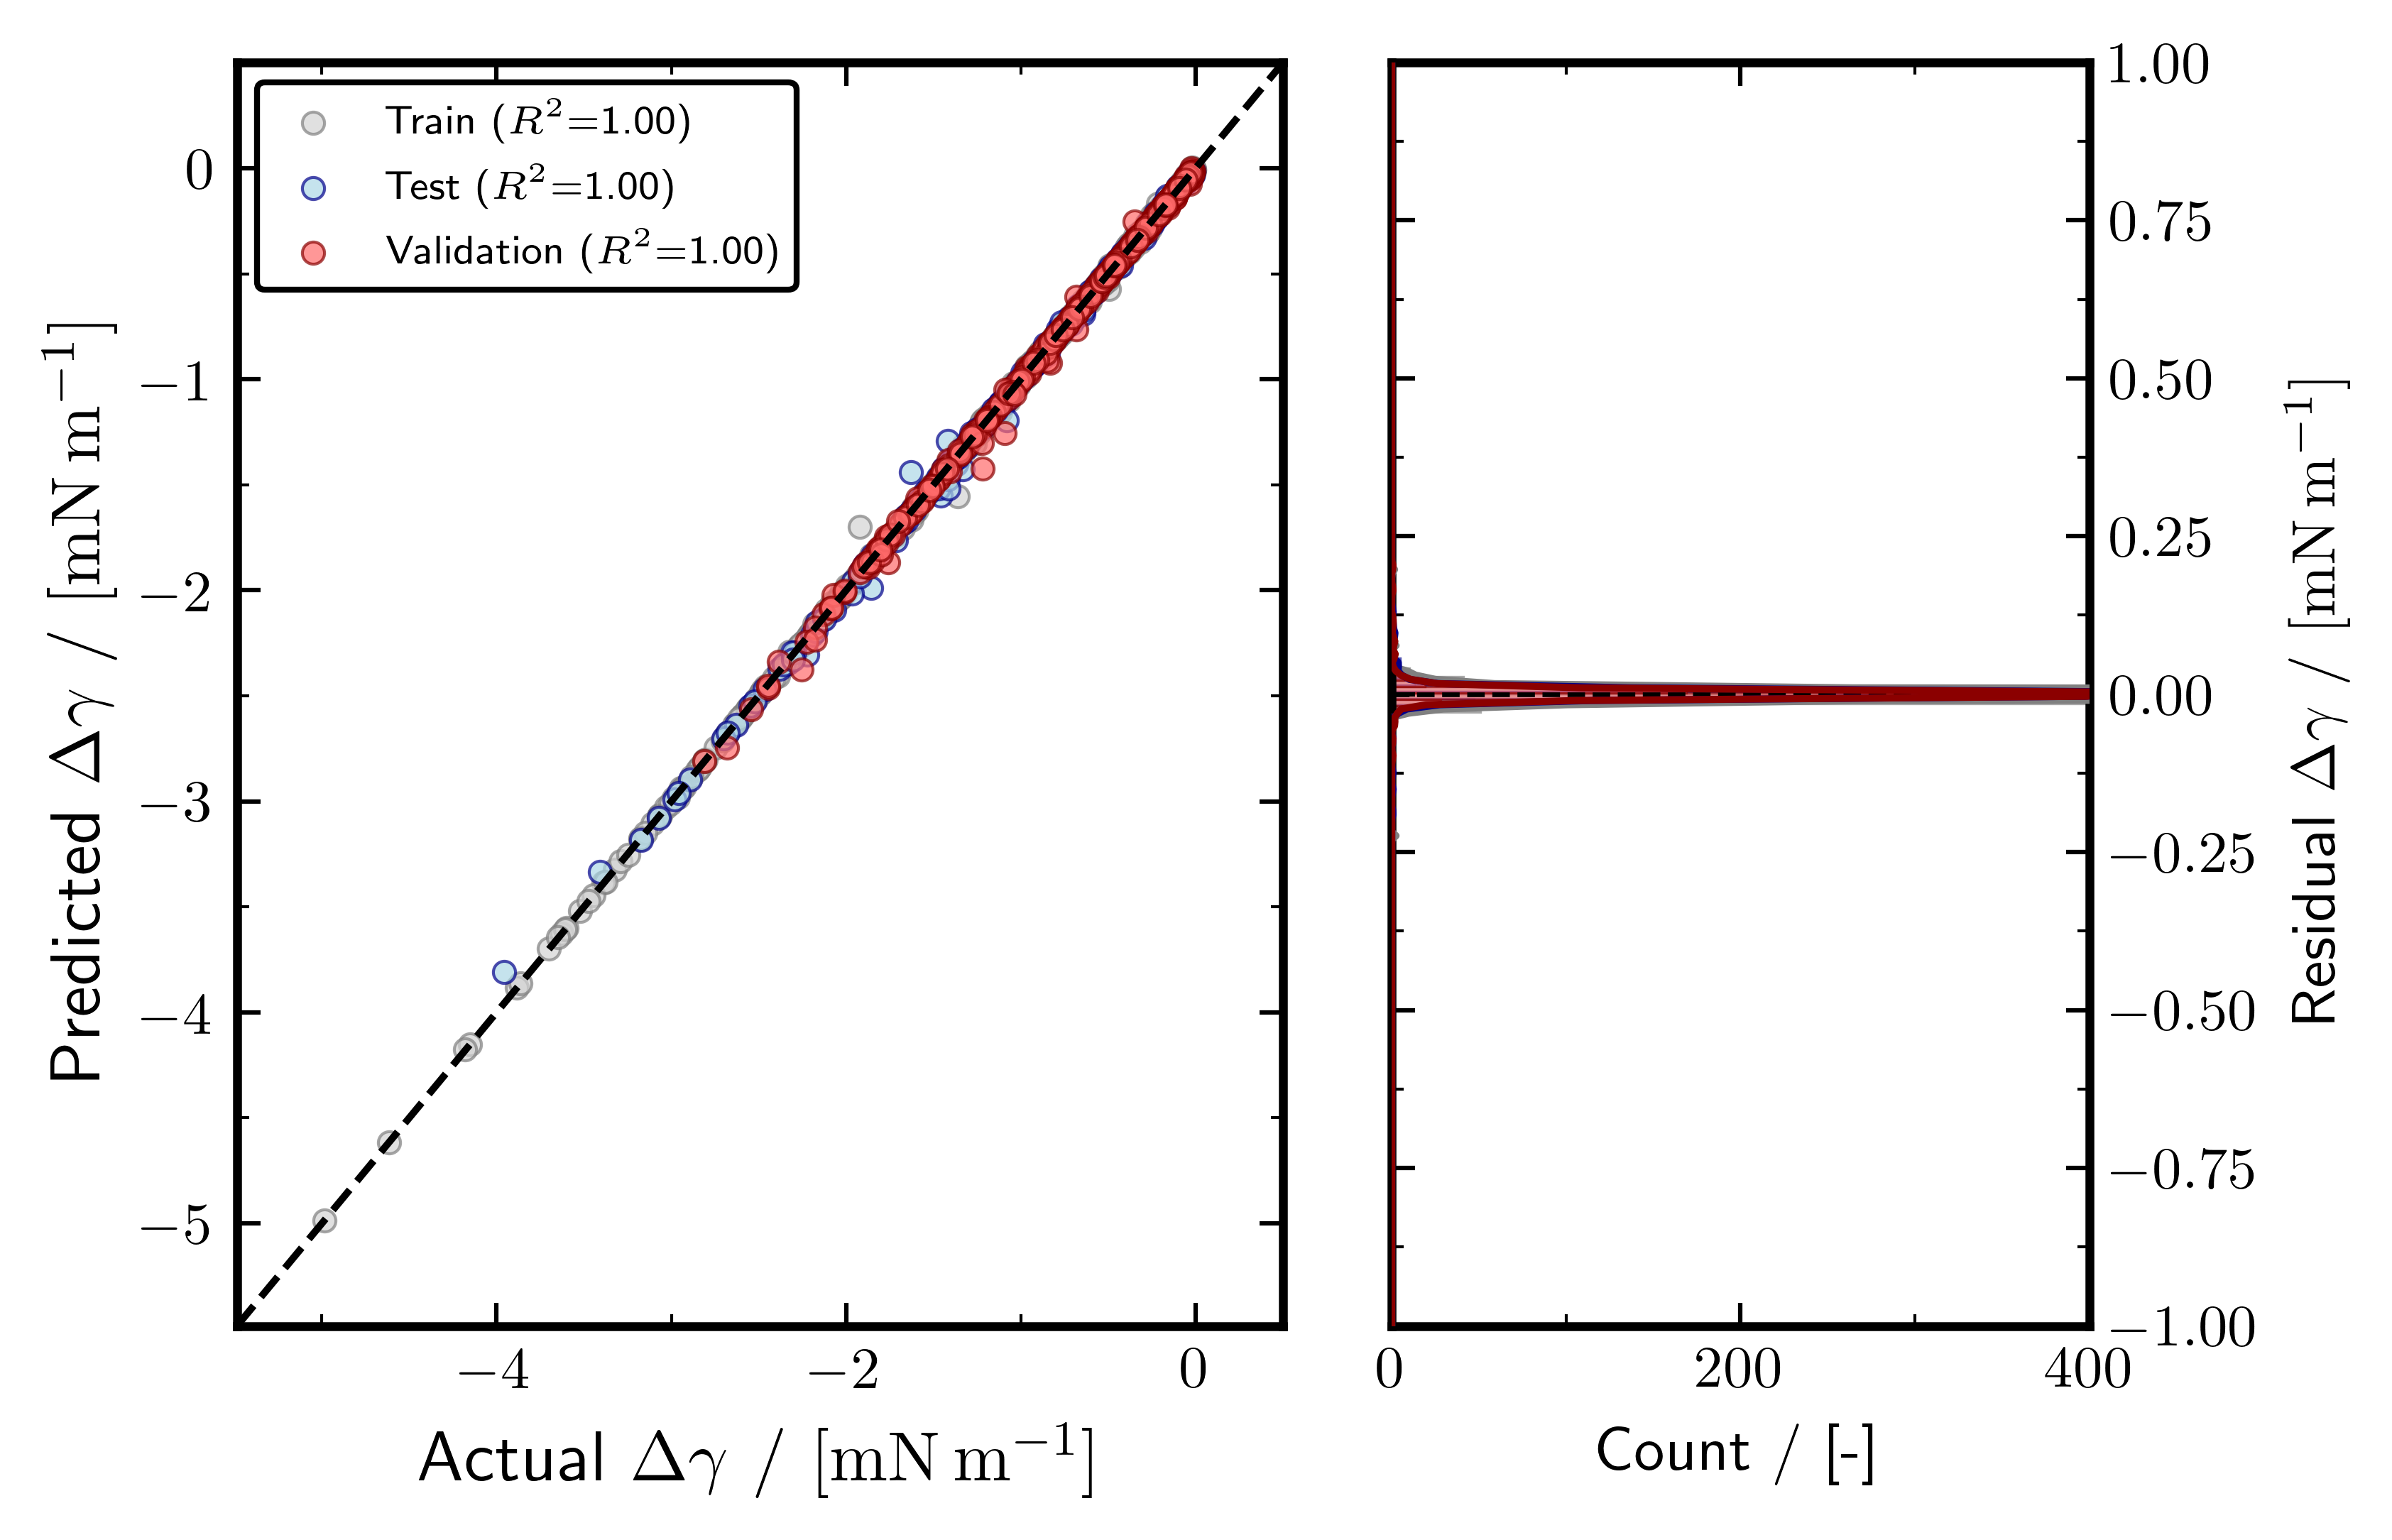

(<Figure size 3300x2100 with 2 Axes>,
 array([<Axes: xlabel='Actual $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='Predicted $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>,
        <Axes: xlabel='Count / [-]', ylabel='Residual $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>],
       dtype=object))

In [8]:
# Parity + residual distribution (combined two-panel figure)
post.plot_parity_with_residual_distribution(
    n_bins      = 30,
    save_path   = "GPR_parity_residual_distribution",
    folder      = OUTPUT_FOLDER,
)

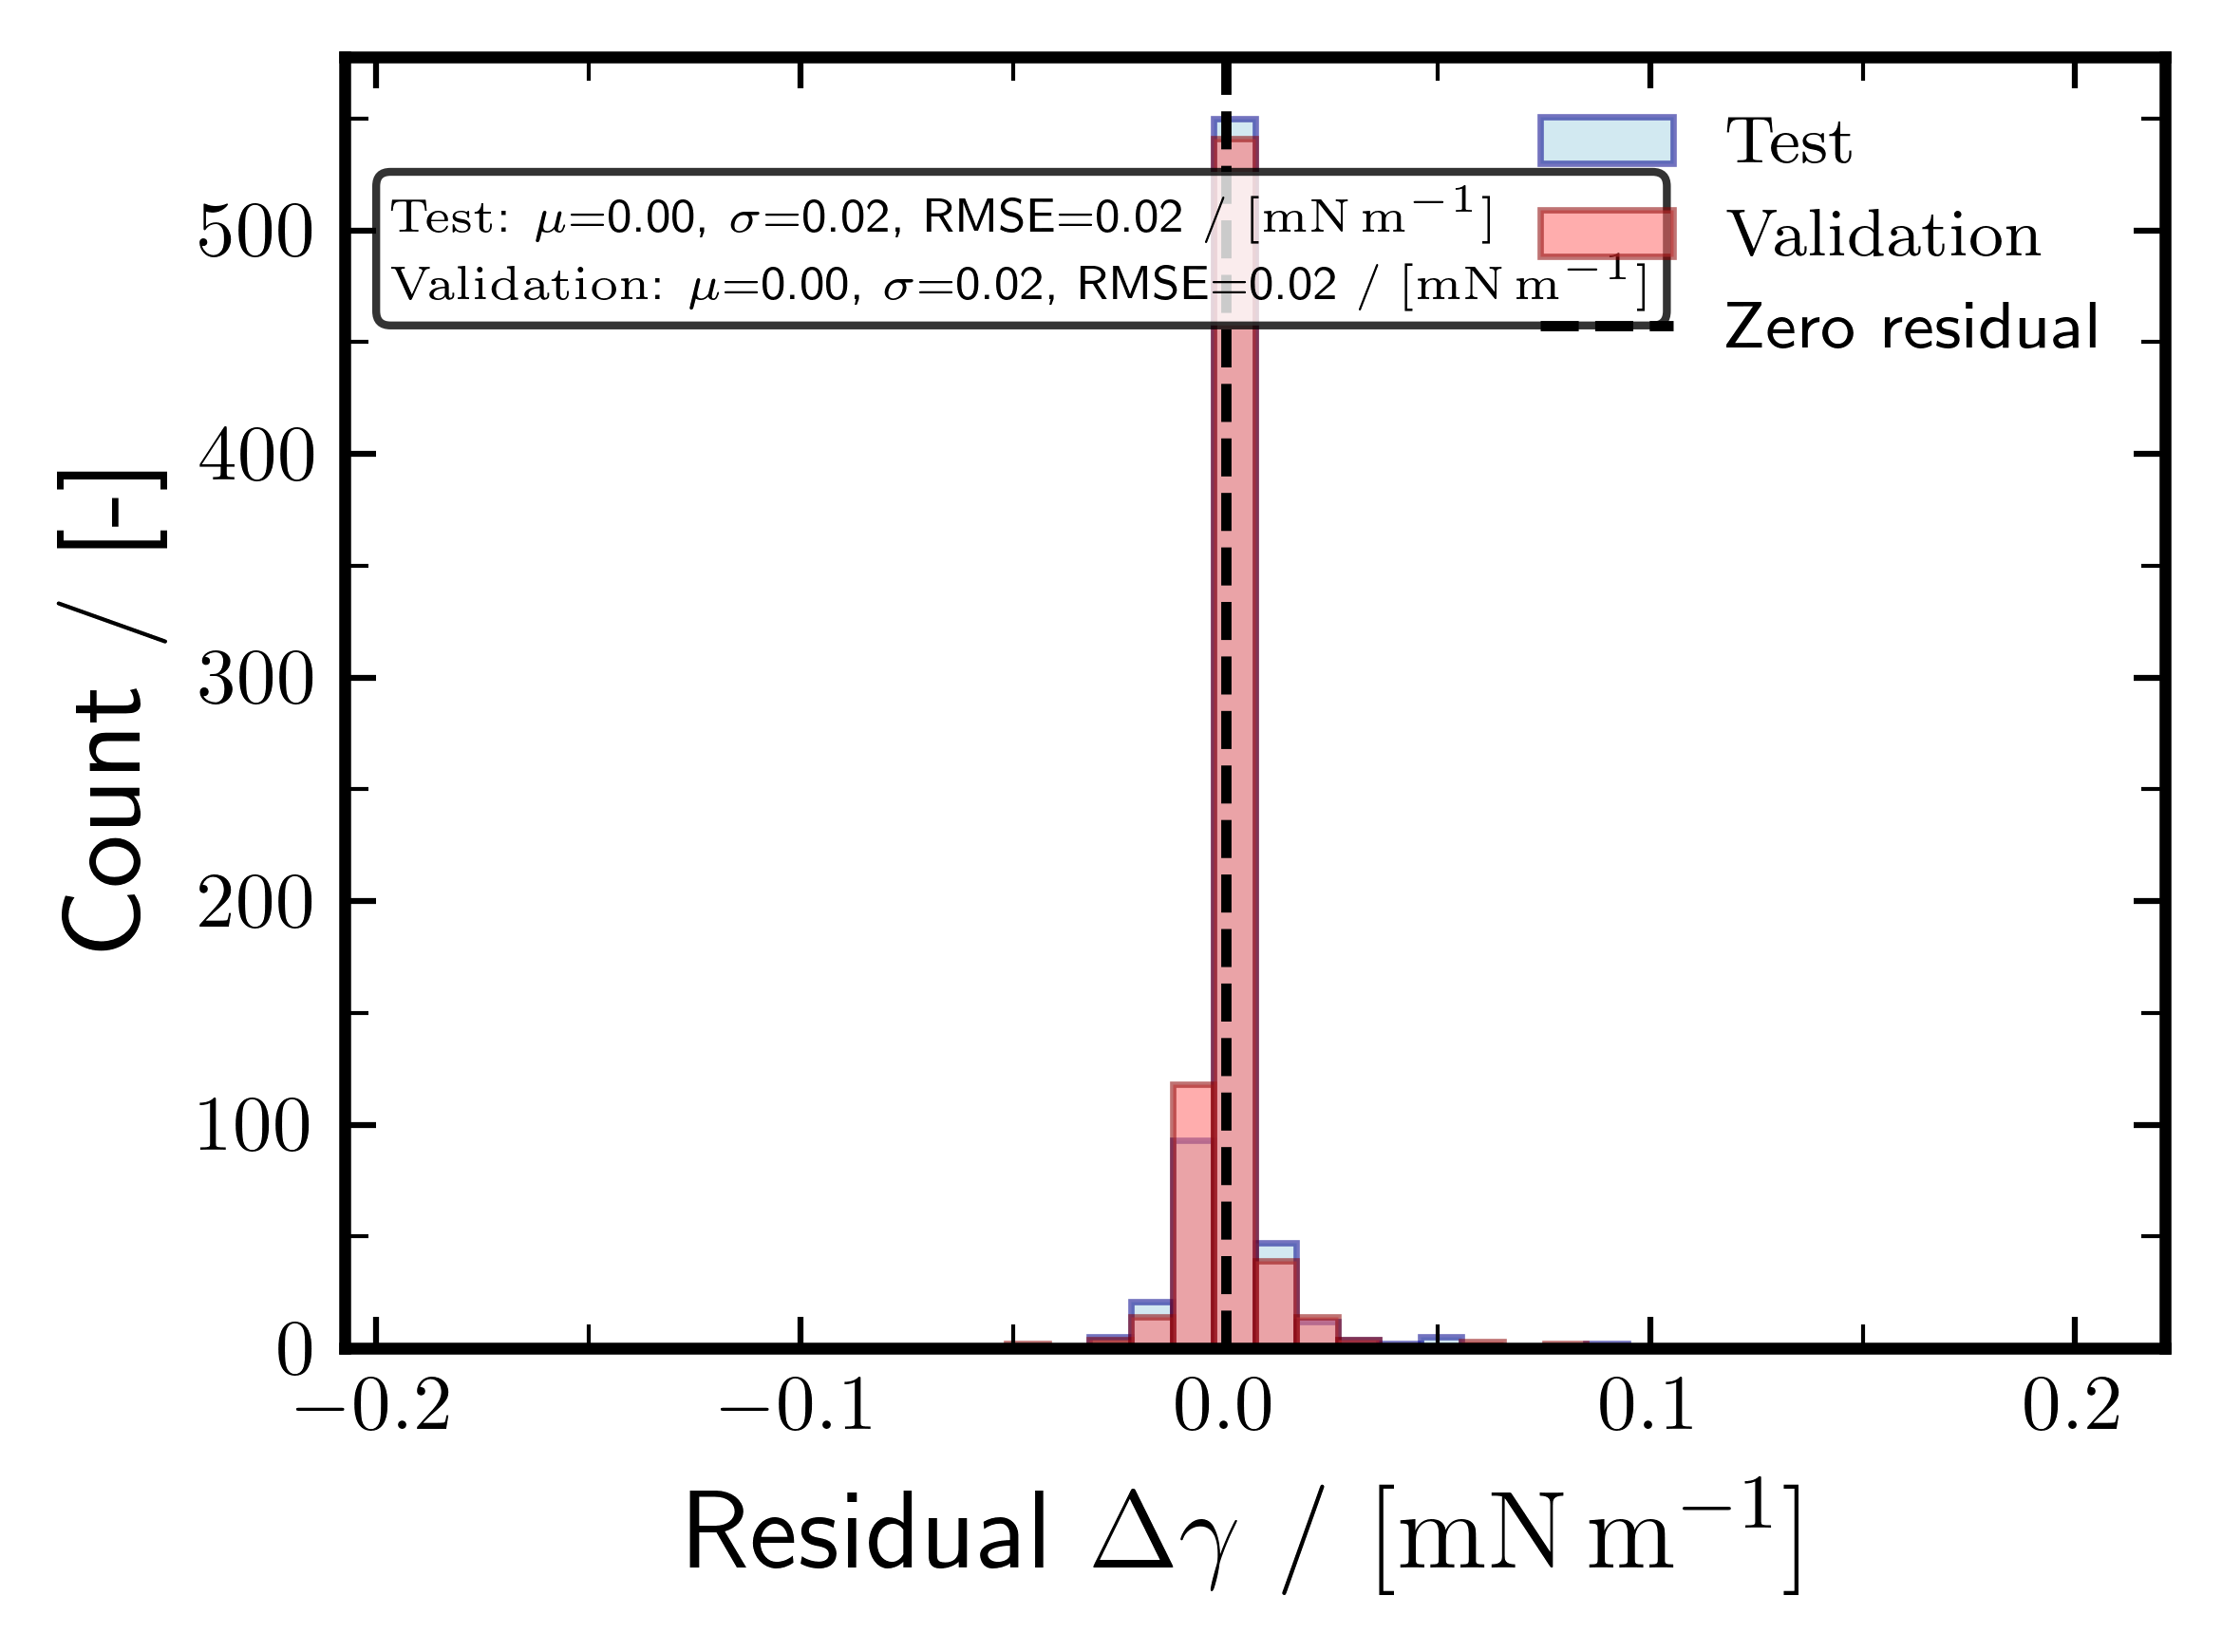

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='Count / [-]'>)

In [9]:
# Residual distribution
post.plot_residual_distribution(save_path="GPR_gamma_residual_distribution", folder=OUTPUT_FOLDER)

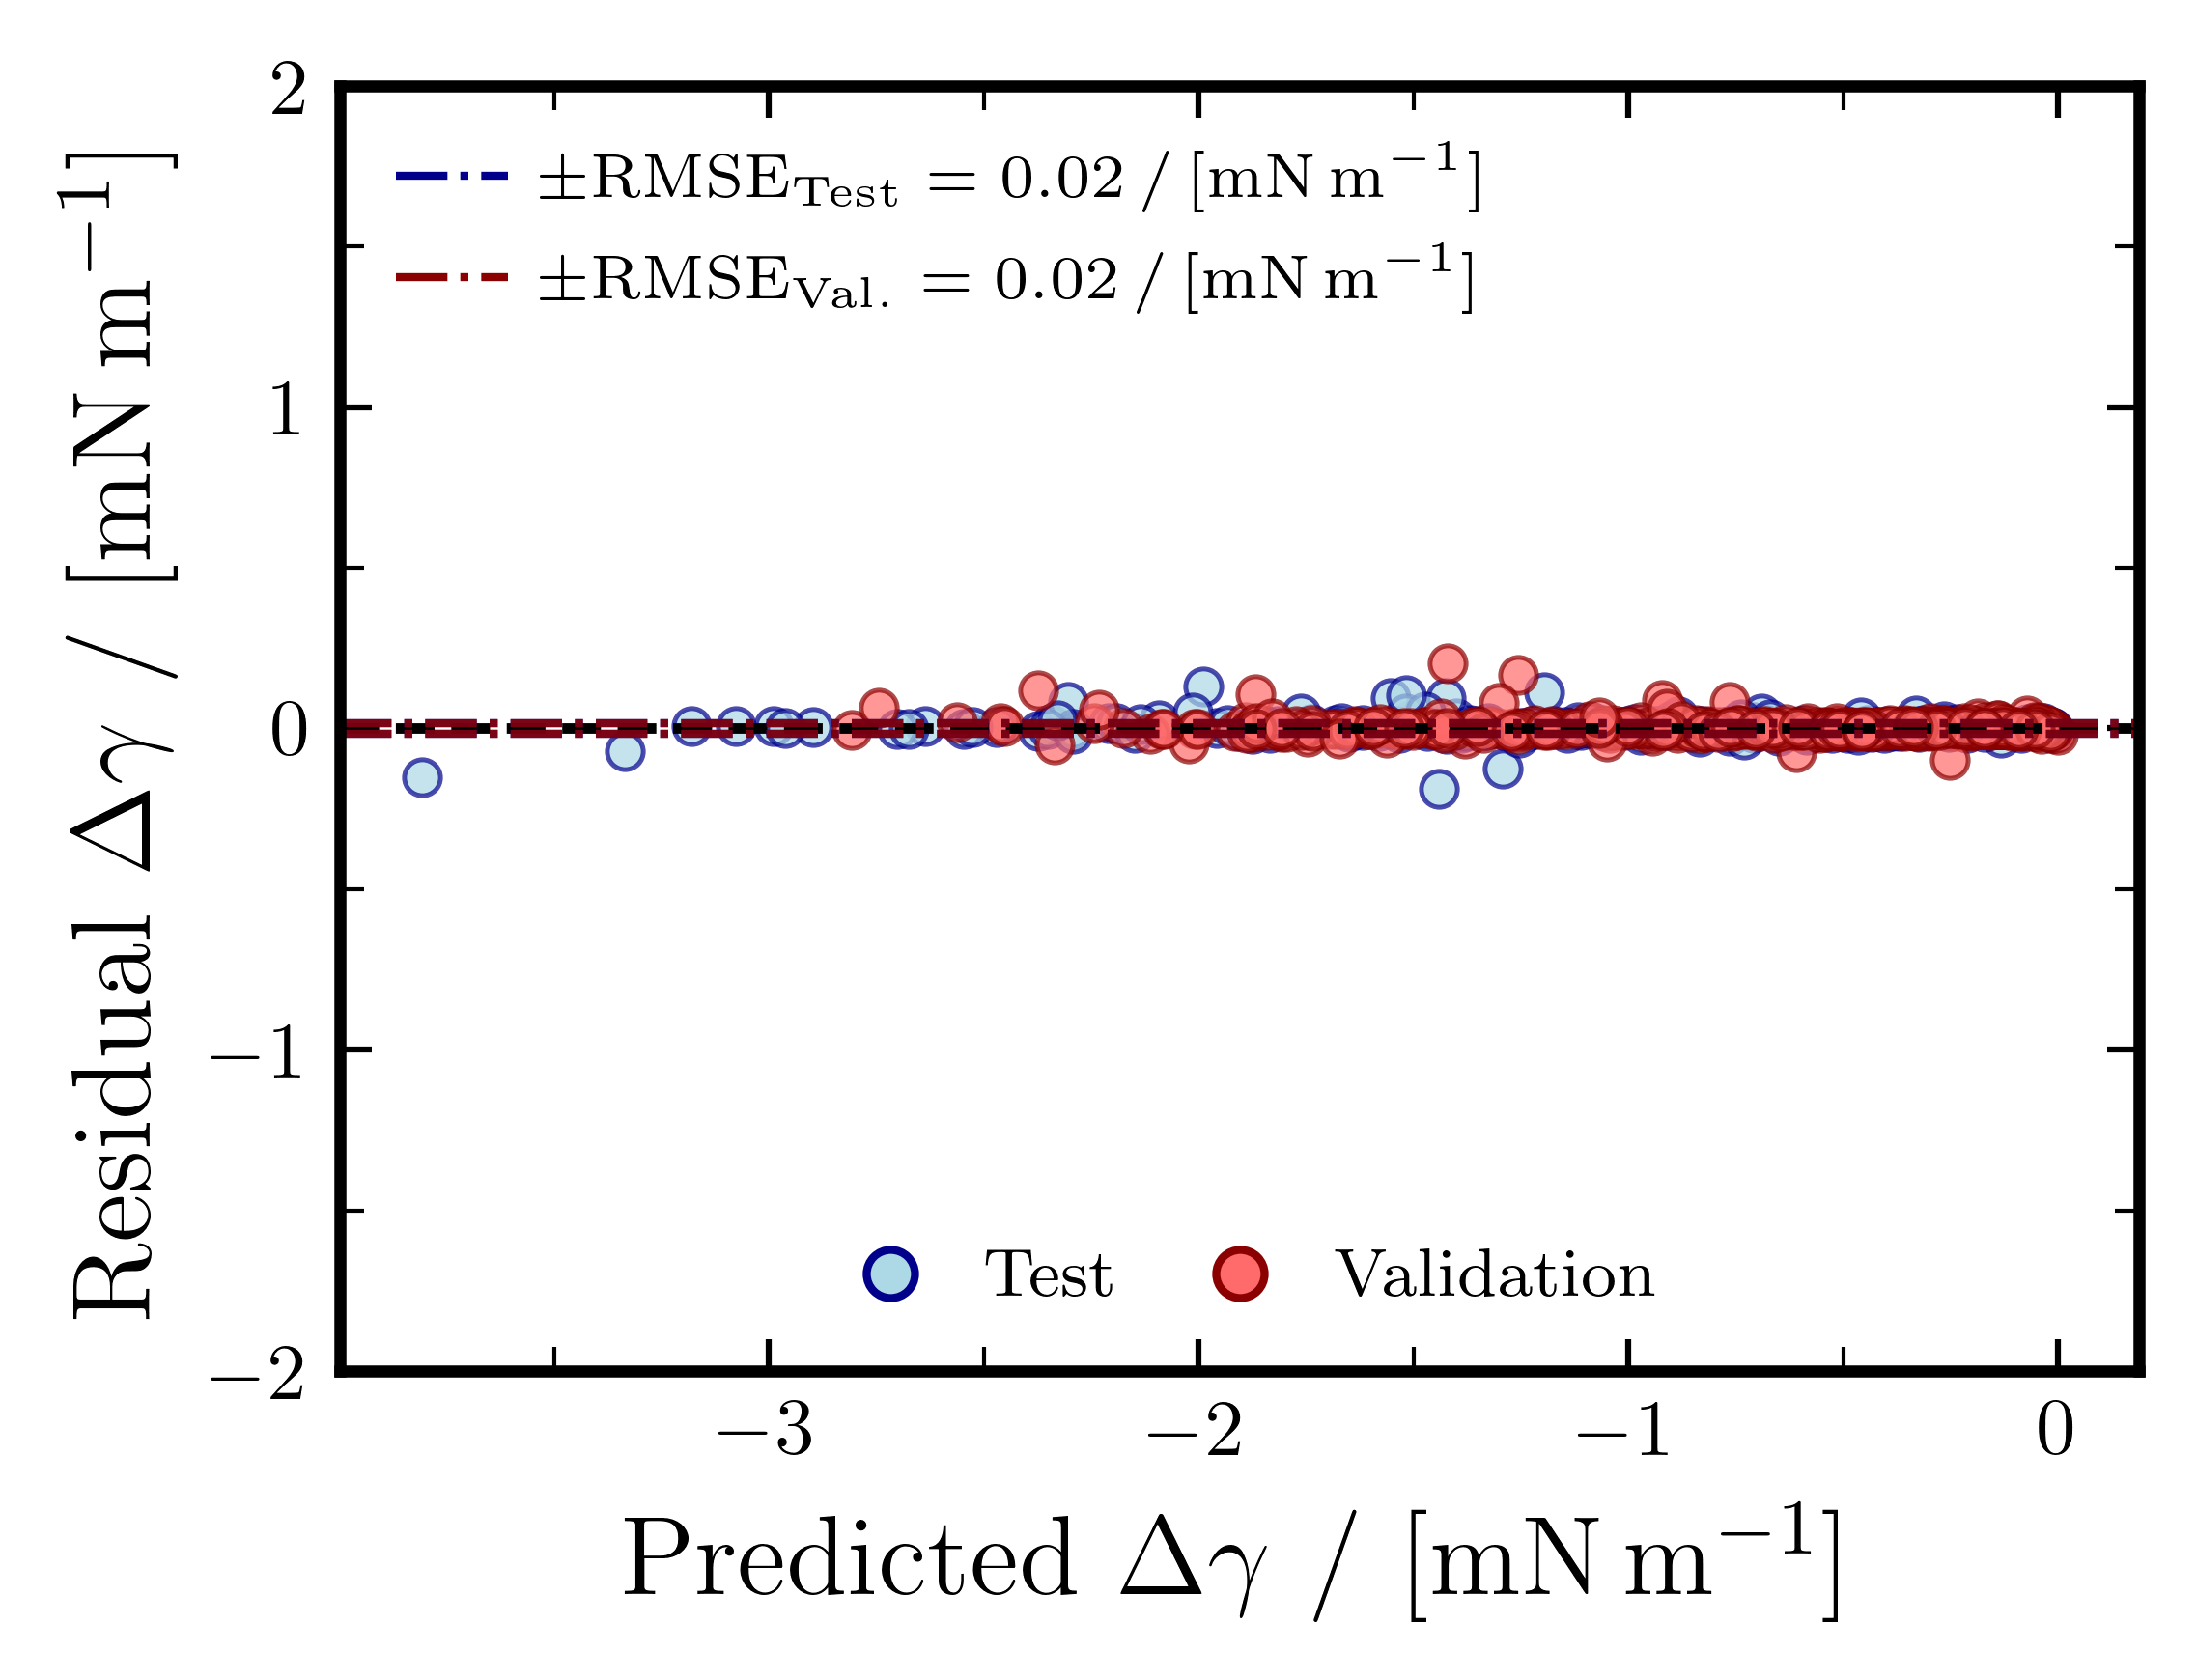

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$\\mathrm{Residual}$ $\\Delta\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [10]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="GPR_gamma_residual_vs_predicted", folder=OUTPUT_FOLDER, 
                                y_range= (-2, 2))

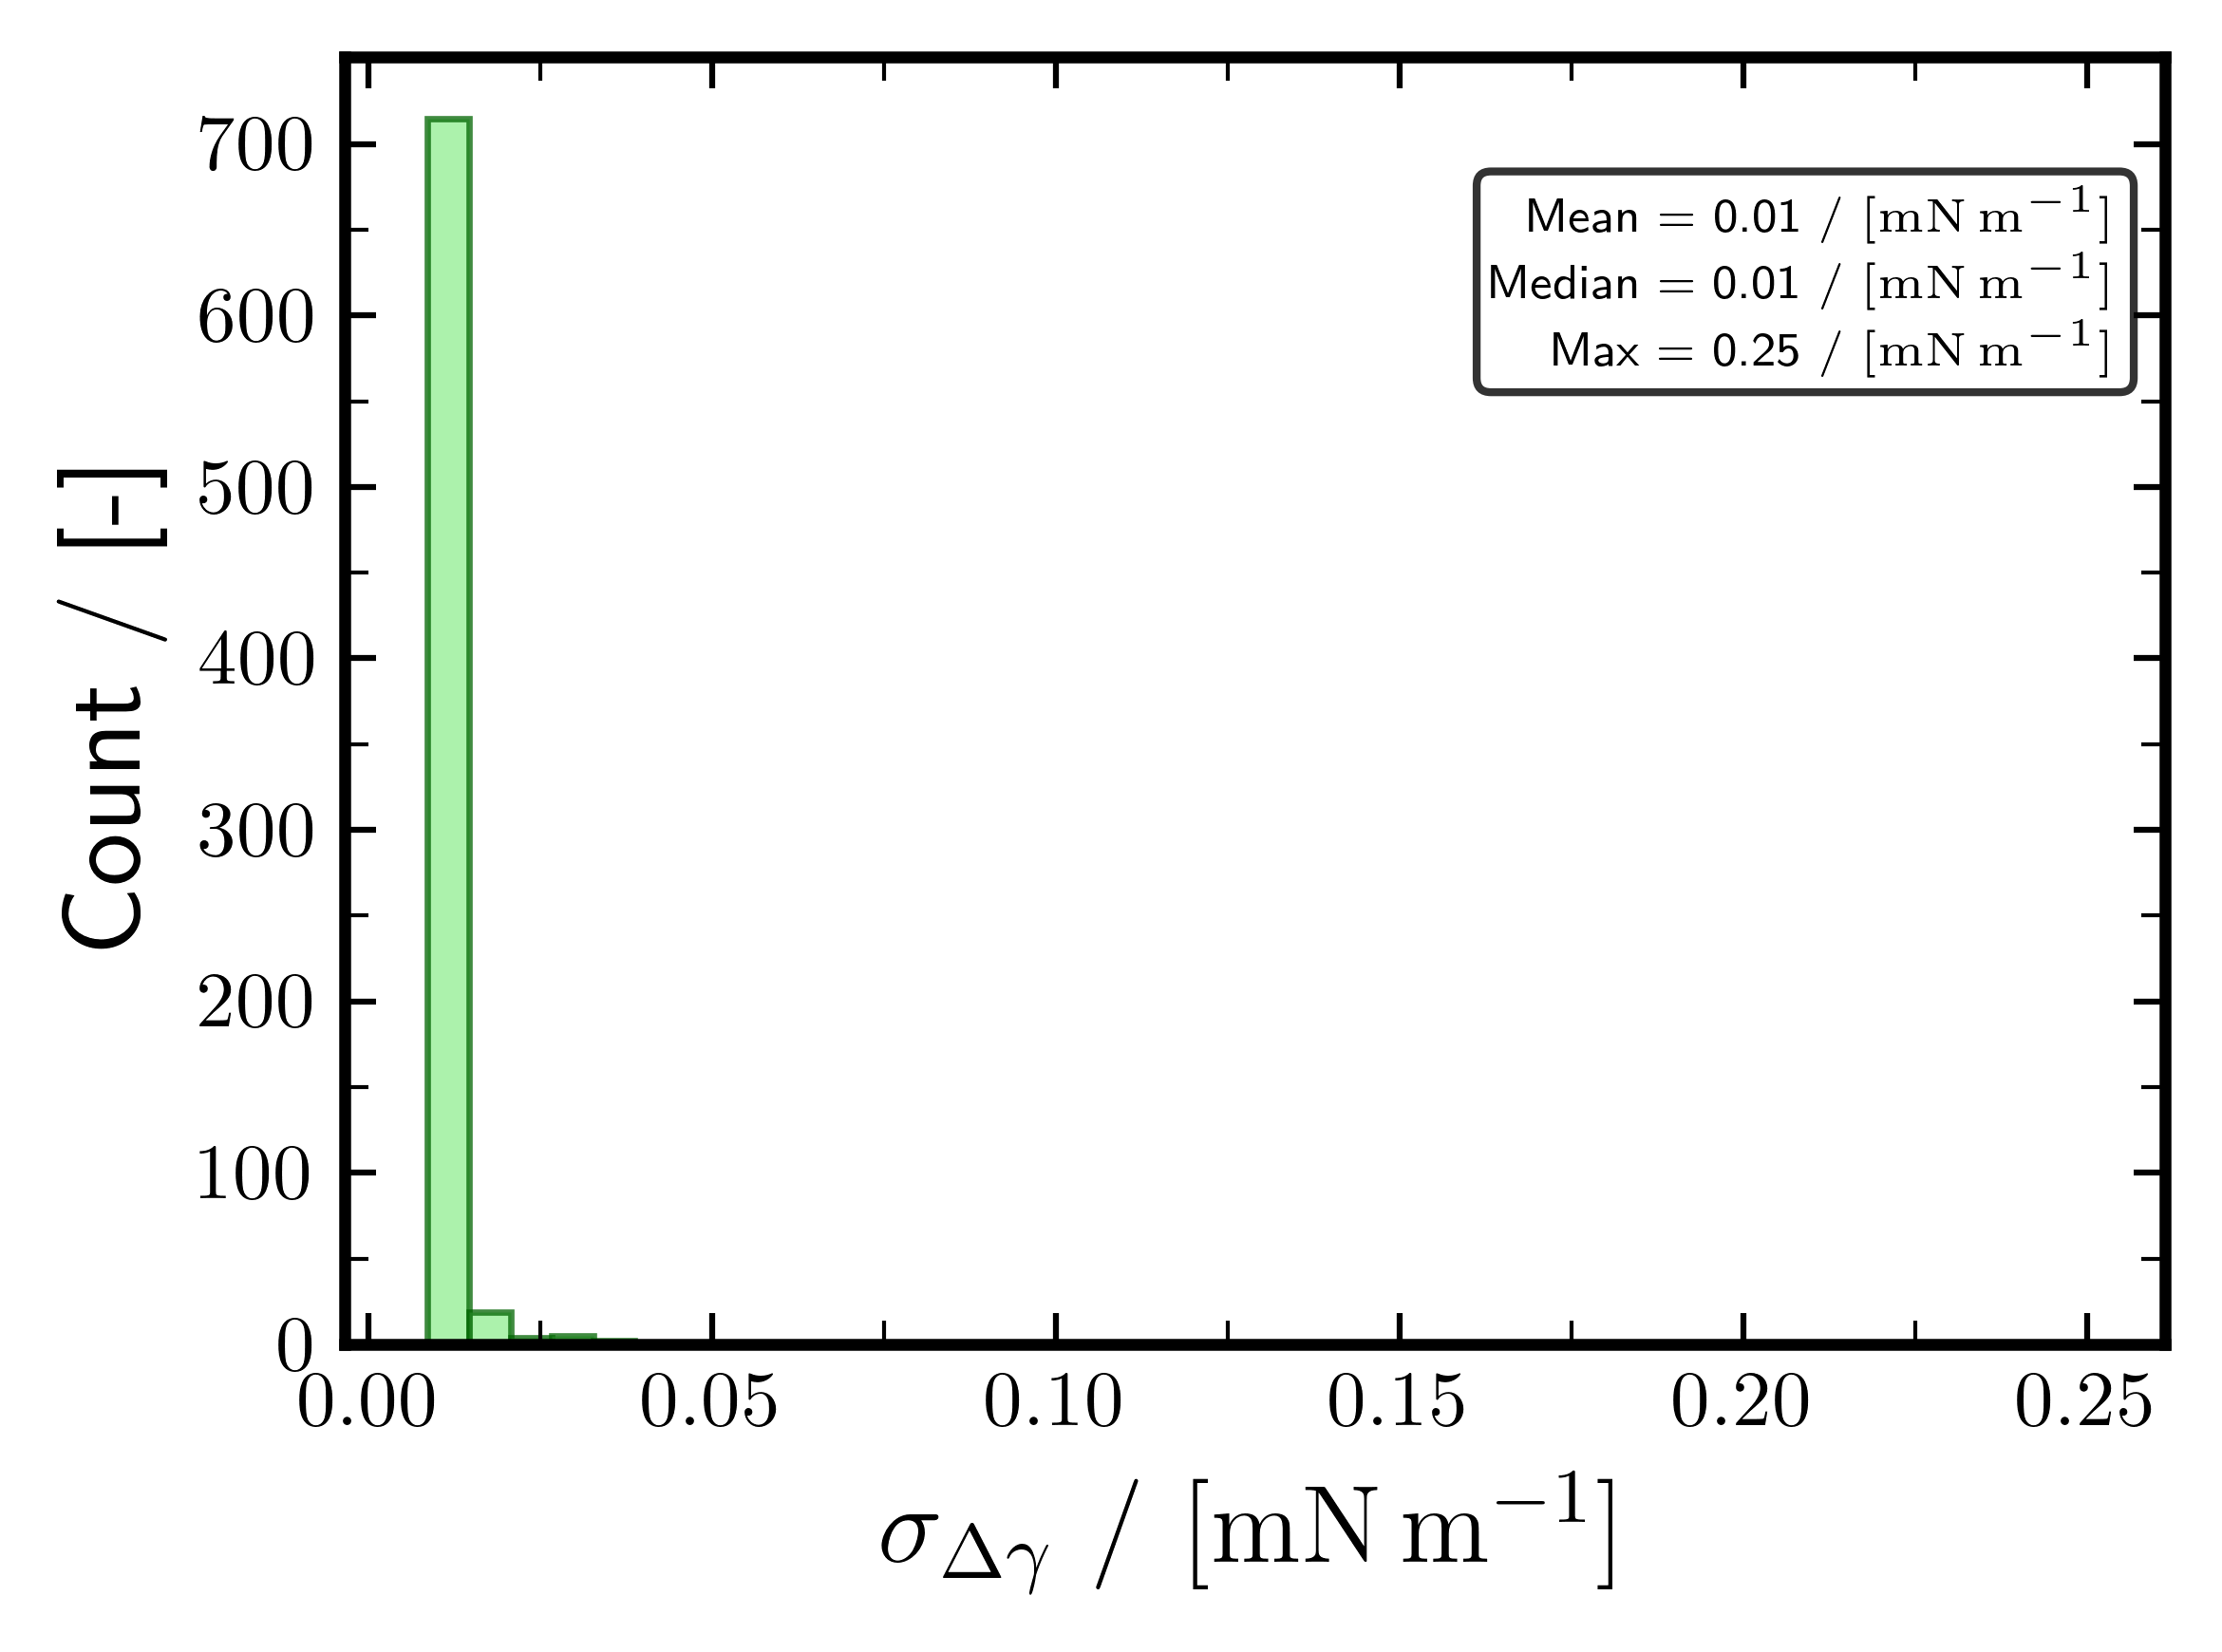

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\sigma_{\\Delta\\gamma}$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='Count / [-]'>)

In [11]:
# GPR: Predictive std histogram
post.plot_std_histogram(y_test_std, save_path="GPR_gamma_std_histogram", folder=OUTPUT_FOLDER)

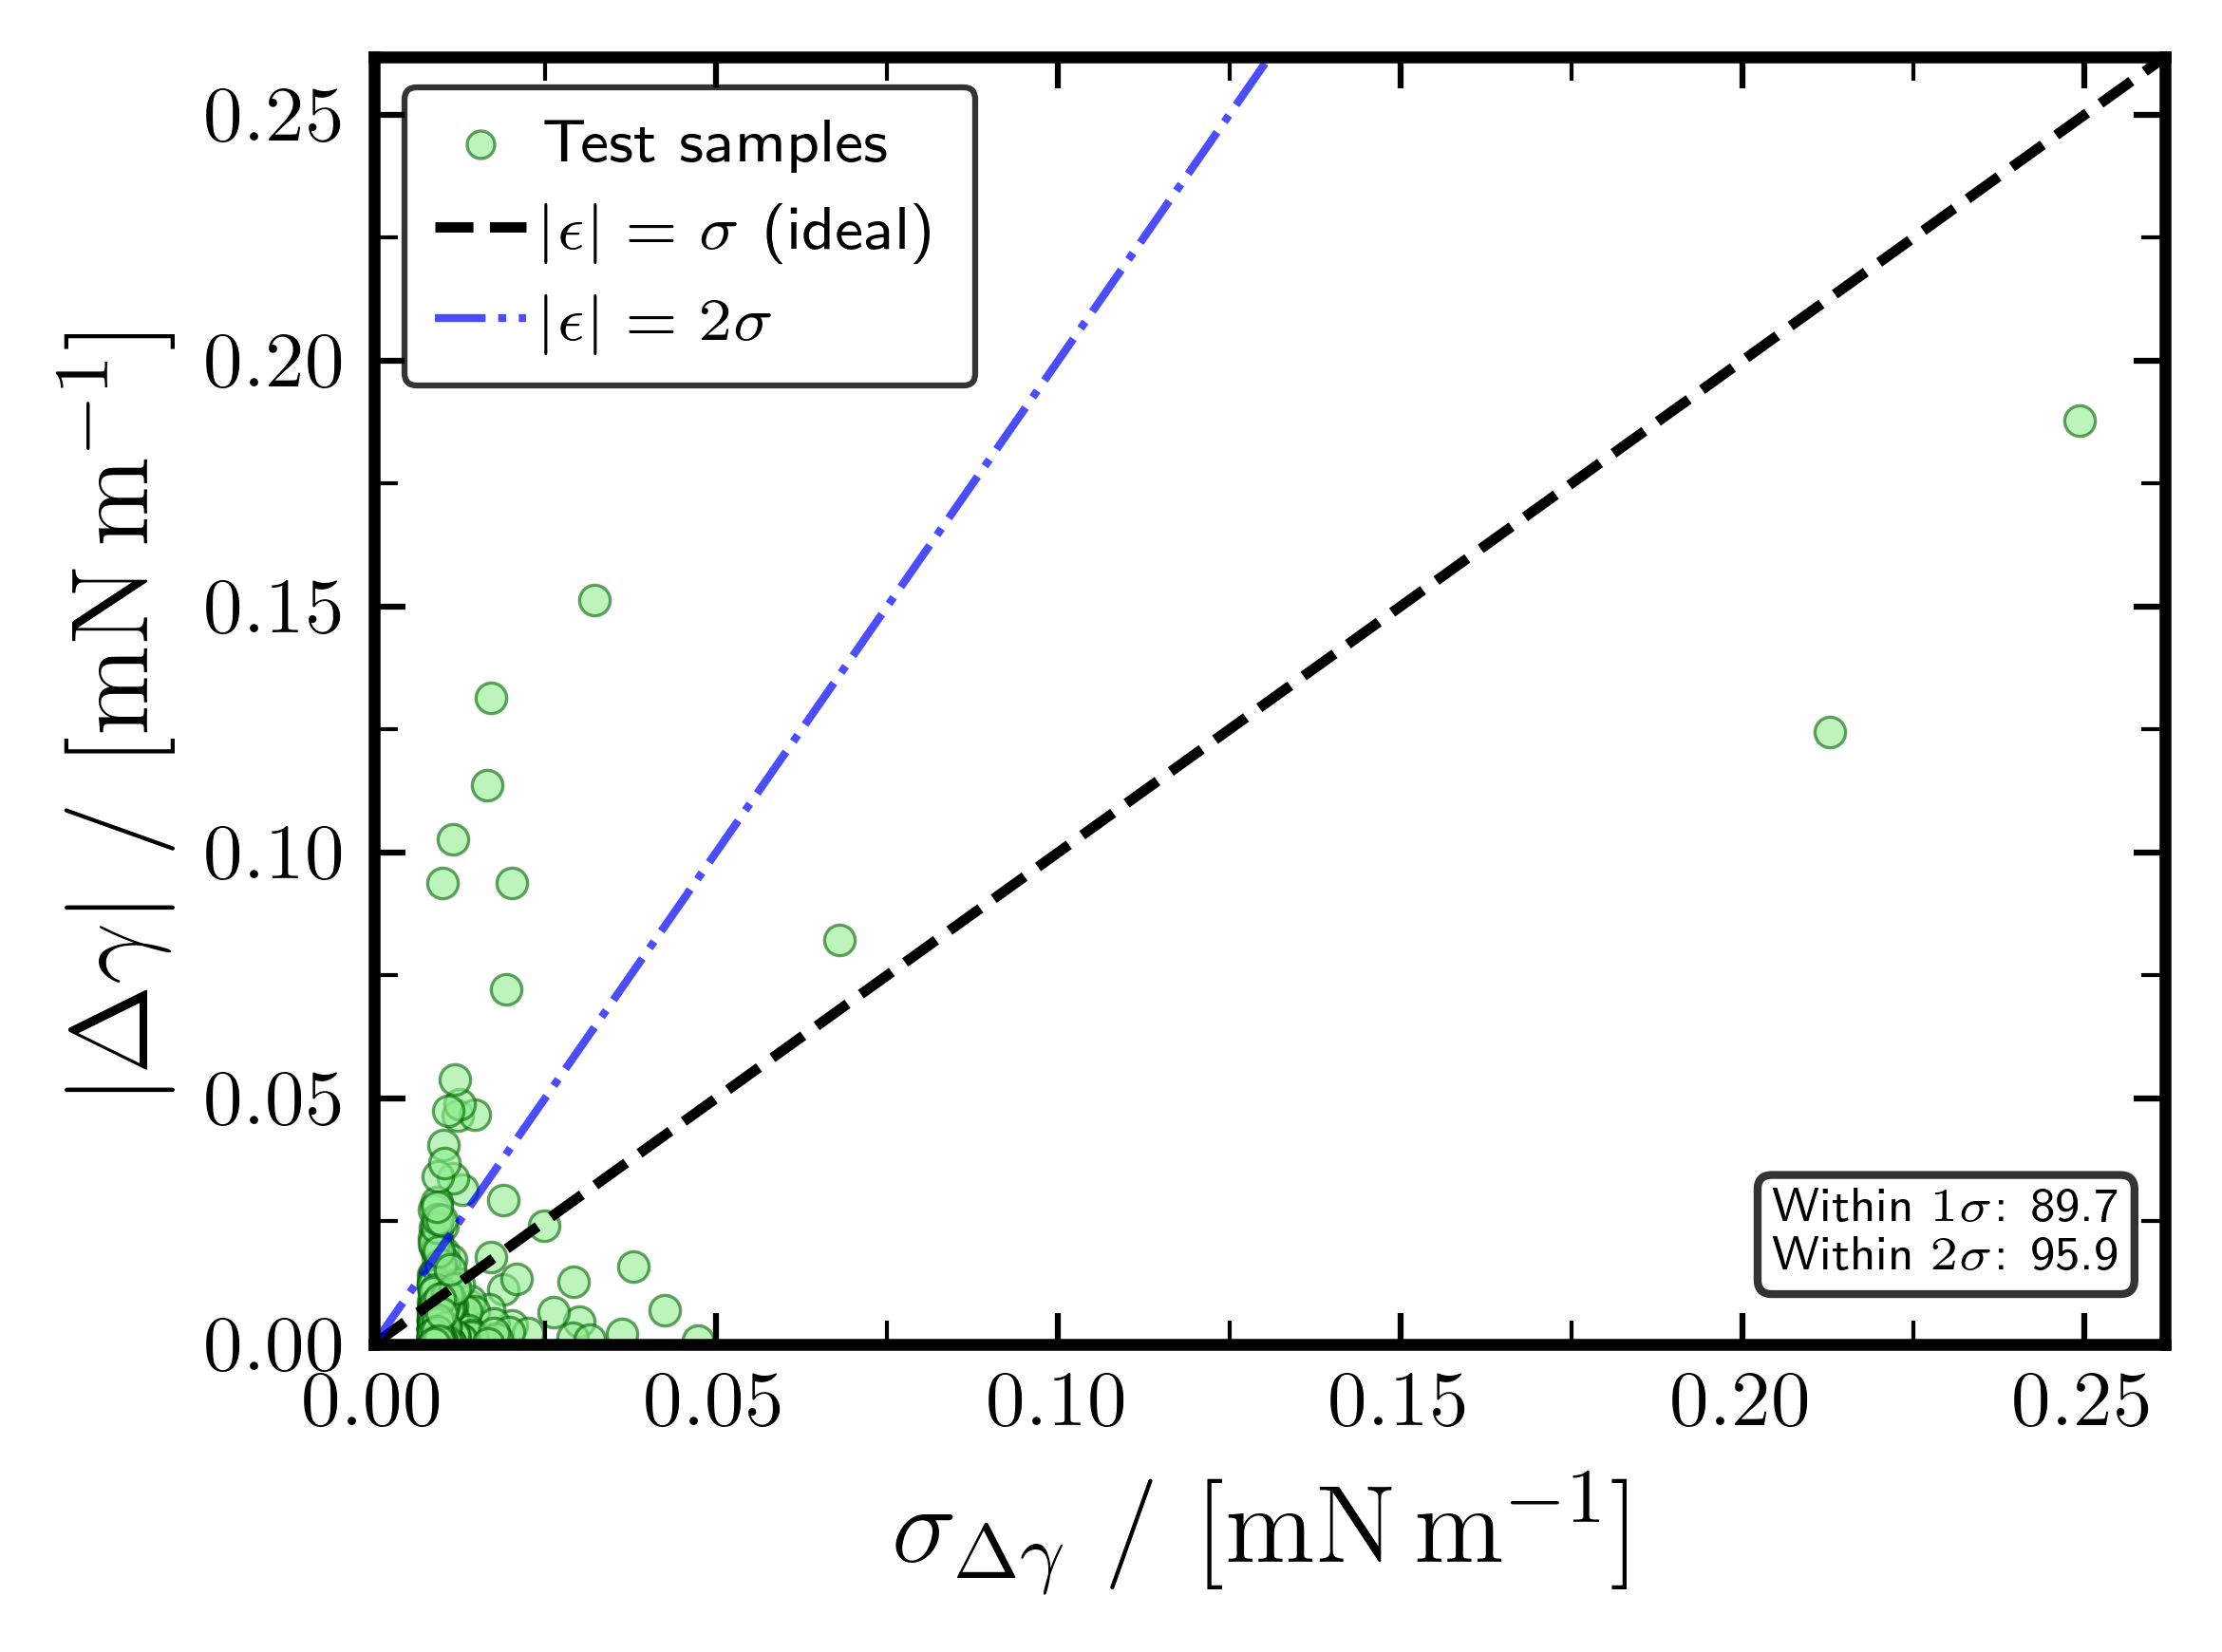

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\sigma_{\\Delta\\gamma}$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$|\\Delta\\gamma|$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [12]:
# GPR: |error| vs predictive std (calibration)
post.plot_error_vs_std(y_test_std, save_path="GPR_gamma_error_vs_std", folder=OUTPUT_FOLDER)

## Response curves & 2D surface


In [13]:
# GPR: Response curves — saved individually per feature
# X_ref = X_train.median().values
# post.plot_response_curves(
#     model               = gpr_model,
#     X_ref               = X_ref,
#     feature_names       = features,
#     X_train             = X_train,
#     n_points            = 100,
#     return_std          = True,
#     save_individually   = True,
#     save_path           = "GPR_gamma_response",
#     folder              = OUTPUT_FOLDER,
# )

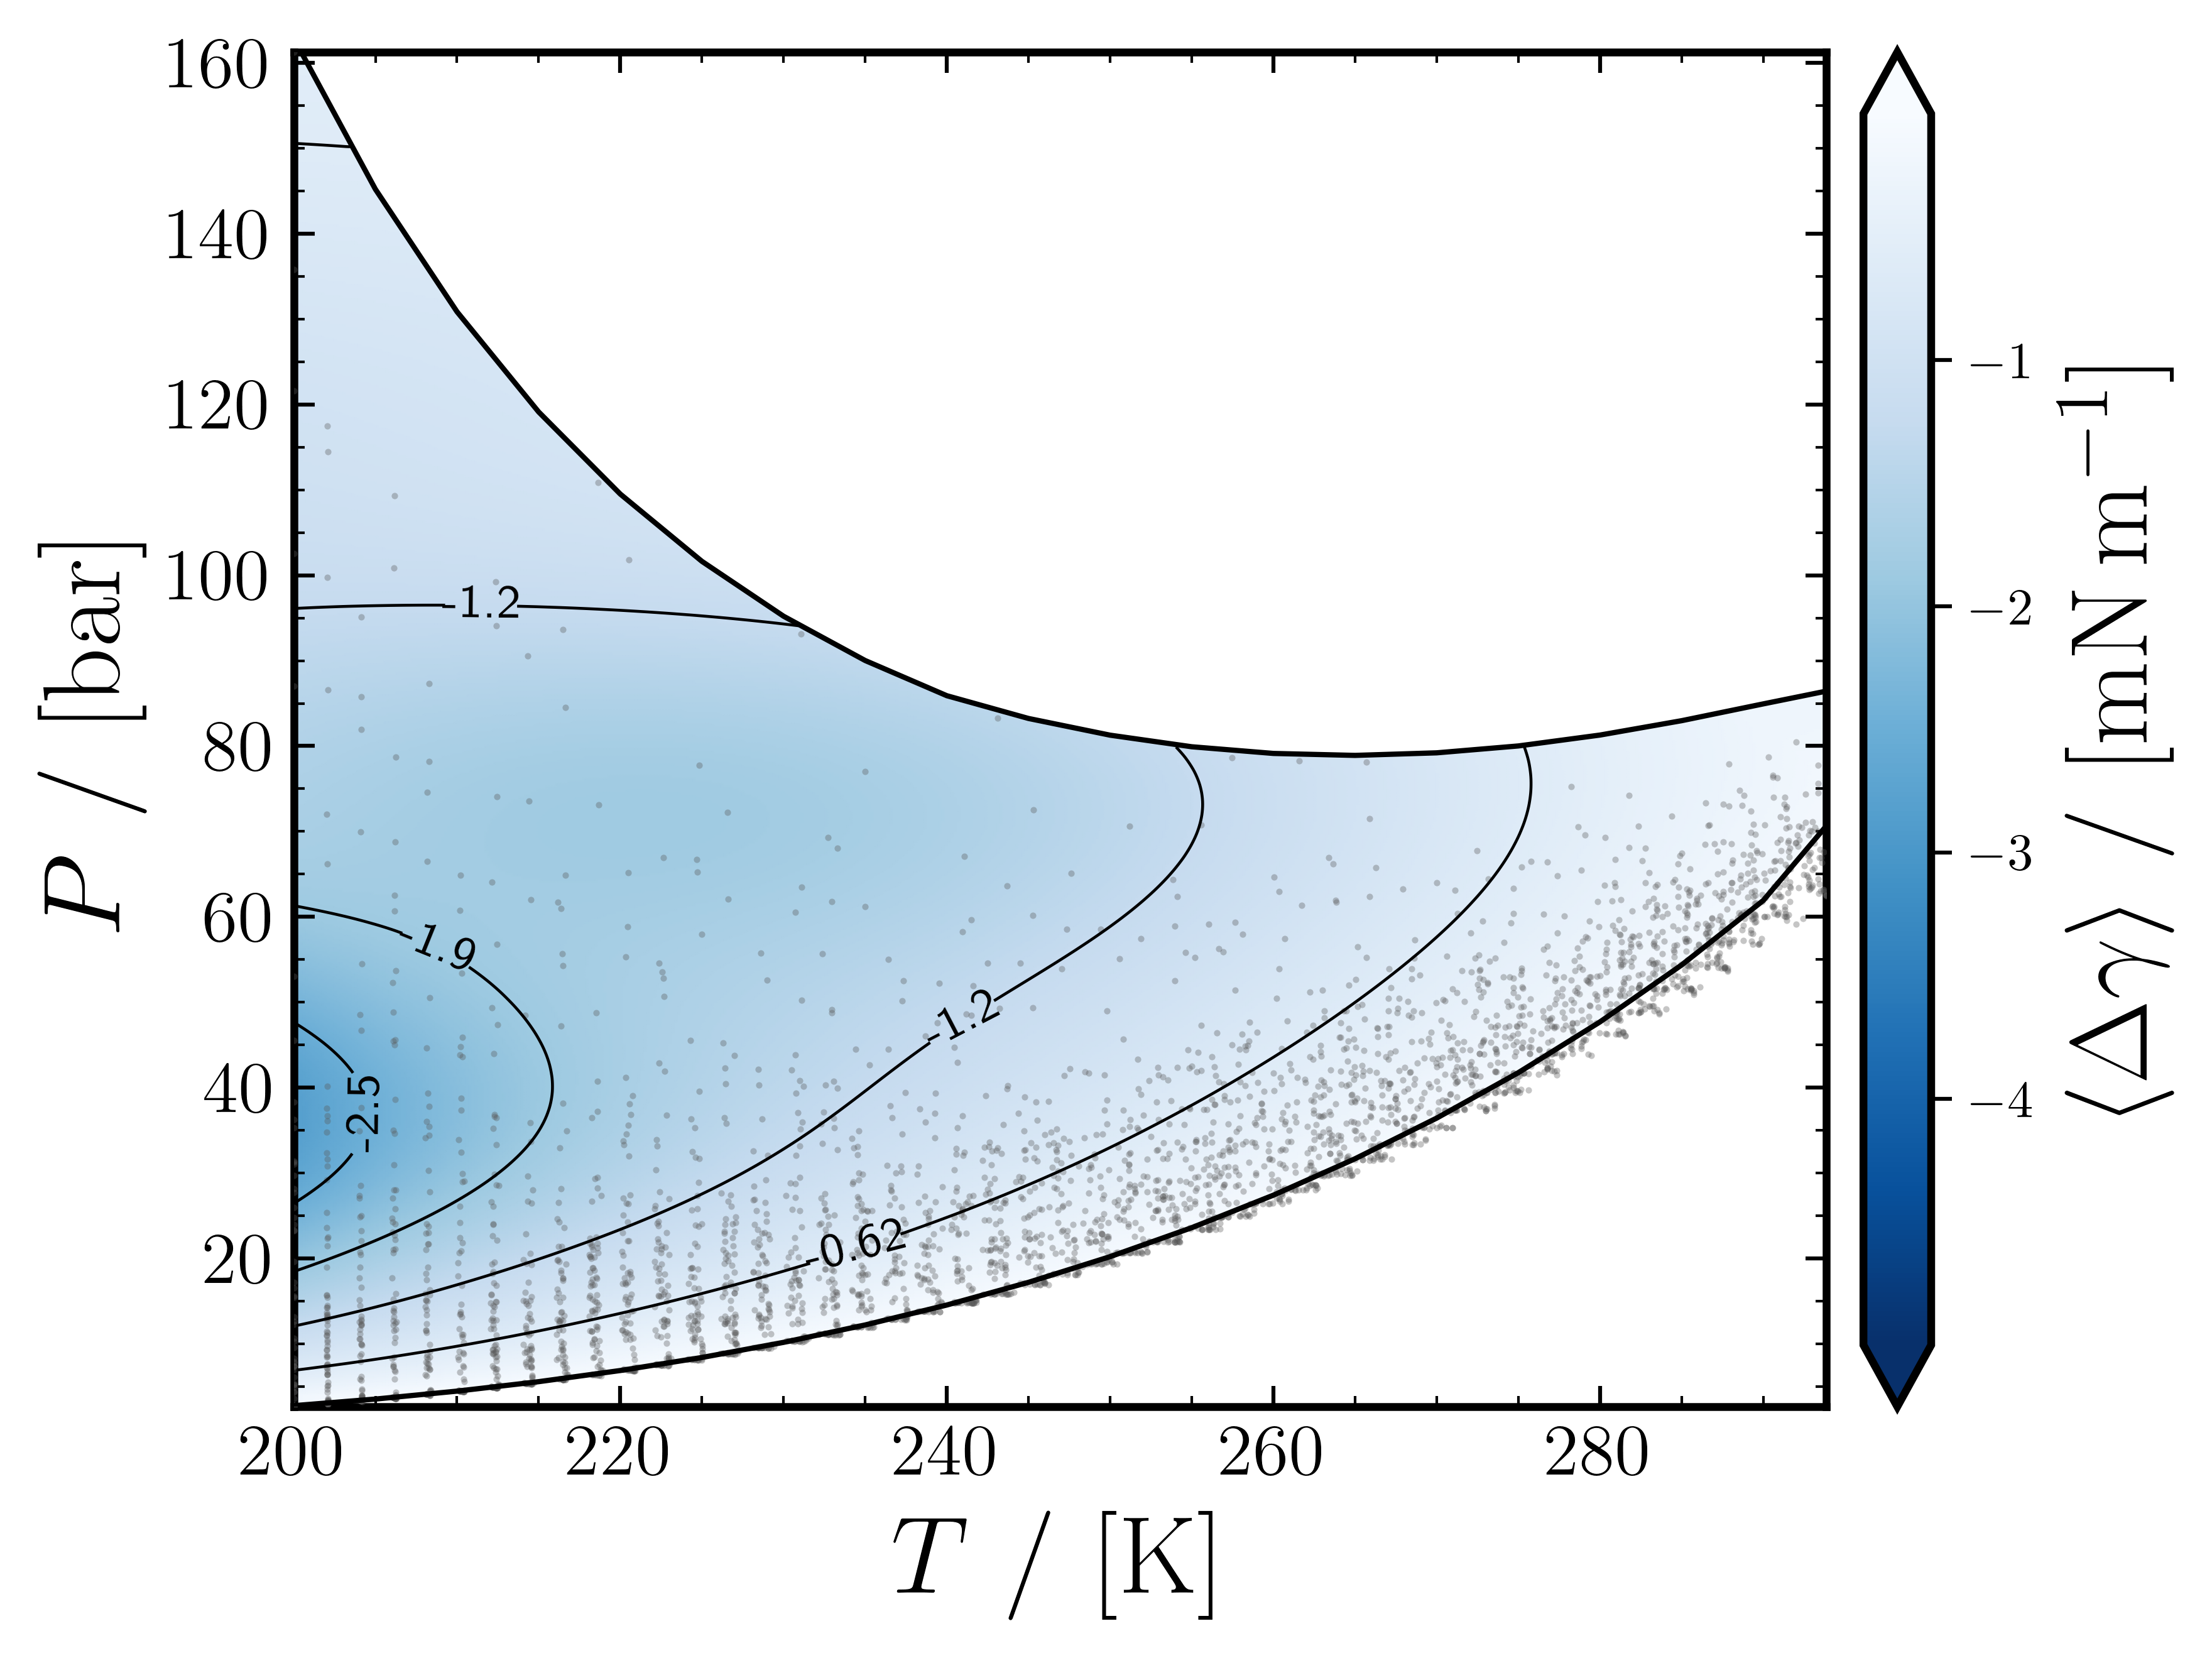

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from scipy.spatial import Delaunay
from scipy.interpolate import interp1d, CloughTocher2DInterpolator, NearestNDInterpolator

# ── Phase envelope (cross-composition max P_bubble / P_dew) ───────────────────
df_env_full = pd.read_csv("../../interfacial_results_dataset_A4.csv")
df_max = (df_env_full.groupby("temperature")[["P_bubble", "P_dew"]]
                     .max().reset_index().sort_values("temperature").dropna())
df_env    = df_max.iloc[:-1].copy()
T_env     = df_env["temperature"].values
P_bub_env = df_env["P_bubble"].values
P_dew_env = df_env["P_dew"].values

bub_interp = interp1d(T_env, P_bub_env, kind="linear", bounds_error=False,
                      fill_value=(P_bub_env[0], P_bub_env[-1]))
dew_interp = interp1d(T_env, P_dew_env, kind="linear", bounds_error=False,
                      fill_value=(P_dew_env[0], P_dew_env[-1]))

# ── Coarse prediction grid + valid-domain mask ────────────────────────────────
T_train_arr = X_train["T"].values
P_train_arr = X_train["P"].values

n_grid = 120
T_vals = np.linspace(T_train_arr.min(), T_train_arr.max(), n_grid)
P_vals = np.linspace(P_train_arr.min(), P_train_arr.max(), n_grid)
TT, PP = np.meshgrid(T_vals, P_vals)

hull    = Delaunay(np.column_stack([T_train_arr, P_train_arr]))
in_hull = hull.find_simplex(np.column_stack([TT.ravel(), PP.ravel()])) >= 0
in_env  = (PP.ravel() <= bub_interp(TT.ravel())) & (PP.ravel() >= dew_interp(TT.ravel()))
mask    = (in_hull & in_env).reshape(n_grid, n_grid)

T_idx, P_idx = features.index("T"), features.index("P")
X_ref = X_train.median().values.copy()
X_grid = np.tile(X_ref, (n_grid * n_grid, 1))
X_grid[:, T_idx] = TT.ravel()
X_grid[:, P_idx] = PP.ravel()

mean_flat = gpr_model.predict(pd.DataFrame(X_grid, columns=features))
mean_grid = mean_flat.reshape(n_grid, n_grid).astype(float)
mean_grid[~mask] = np.nan

# ── Dense smooth field — two versions (fill for pcolormesh, masked for contour)
valid_pts  = np.column_stack([TT[~np.isnan(mean_grid)], PP[~np.isnan(mean_grid)]])
valid_vals = mean_grid[~np.isnan(mean_grid)]
ct_interp  = CloughTocher2DInterpolator(valid_pts, valid_vals)
nn_fill    = NearestNDInterpolator(valid_pts, valid_vals)

n_smooth = 500
T_vals_s = np.linspace(T_train_arr.min(), T_train_arr.max(), n_smooth)
P_vals_s = np.linspace(P_train_arr.min(), P_train_arr.max(), n_smooth)
TT_s, PP_s = np.meshgrid(T_vals_s, P_vals_s)

in_hull_s = hull.find_simplex(np.column_stack([TT_s.ravel(), PP_s.ravel()])) >= 0
in_env_s  = (PP_s.ravel() <= bub_interp(TT_s.ravel())) & (PP_s.ravel() >= dew_interp(TT_s.ravel()))
mask_s    = (in_hull_s & in_env_s).reshape(n_smooth, n_smooth)

Z_full = ct_interp(TT_s, PP_s)
nan_holes = np.isnan(Z_full)
Z_full[nan_holes] = nn_fill(TT_s[nan_holes], PP_s[nan_holes])

Z_for_contour = np.where(mask_s, Z_full, np.nan)
Z_for_contour = np.ma.masked_invalid(Z_for_contour)

vmin = -5.0   # fixed colourbar range
vmax =  0.0
line_levels = np.linspace(vmin, vmax, 9)

# ── Envelope clip polygon (full T-grid so no gap at low T) ────────────────────
clip_T_seq = T_vals_s
clip_P_top = bub_interp(clip_T_seq)
clip_P_bot = dew_interp(clip_T_seq)
clip_T = np.concatenate([clip_T_seq, clip_T_seq[::-1]])
clip_P = np.concatenate([clip_P_top, clip_P_bot[::-1]])
clip_path = Path(np.column_stack([clip_T, clip_P]), closed=True)

def _apply_clip(artist, patch):
    try:
        artist.set_clip_path(patch)
    except AttributeError:
        for coll in getattr(artist, "collections", []):
            coll.set_clip_path(patch)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = ps.plot_init(w=6, h=4.5)
clip_patch = PathPatch(clip_path, facecolor="none", edgecolor="none",
                       transform=ax.transData)
ax.add_patch(clip_patch)

pcm = ax.pcolormesh(TT_s, PP_s, Z_full,
                    cmap="Blues_r", vmin=vmin, vmax=vmax,
                    shading="gouraud", zorder=1)
_apply_clip(pcm, clip_patch)

ax.scatter(T_train_arr, P_train_arr, color="0.35", s=1.5, alpha=0.35,
           linewidths=0, zorder=3)

cs = ax.contour(TT_s, PP_s, Z_for_contour, levels=line_levels,
                colors="black", linewidths=0.55, linestyles="solid",
                corner_mask=True, zorder=6)
_apply_clip(cs, clip_patch)
ax.clabel(cs, inline=True, inline_spacing=3,
          fontsize=ps.label_fontsize * 0.65, fmt="%.2g")

ax.plot(T_env, P_bub_env, "-", color='k',
        linewidth=ps.linewidth, markersize=ps.markersize, zorder=7)
ax.plot(T_env, P_dew_env, "-", color='k',
        linewidth=ps.linewidth, markersize=ps.markersize, zorder=7)

cbar = fig.colorbar(pcm, ax=ax, pad=0.02, extend="both")
cbar.set_label(
    r"$\langle\Delta\gamma\rangle\ /\ [\mathrm{mN}\,\mathrm{m}^{-1}]$",
    fontsize=ps.label_fontsize*1.5)
cbar.ax.tick_params(labelsize=ps.label_fontsize*2)
ps.style_colorbar(cbar)
cbar.set_ticks([-4, -3, -2, -1])  # exclude 0 and -5 endpoints

ax.set_xlabel(r"$T\ /\ [\mathrm{K}]$", fontsize=ps.label_fontsize*1.5)
ax.set_ylabel(r"$P\ /\ [\mathrm{bar}]$", fontsize=ps.label_fontsize*1.5)
ax.tick_params(which="both", direction="in", top=True, right=True, labelsize=ps.label_fontsize)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.set_xlim(T_train_arr.min(), T_train_arr.max())
ax.set_ylim(P_train_arr.min(), P_train_arr.max())

plt.tight_layout()
ps.save_plot(fig, "GPR_2D_response_T_P", folder=OUTPUT_FOLDER)
plt.show()

## Reconstructed γ_cDFT parity


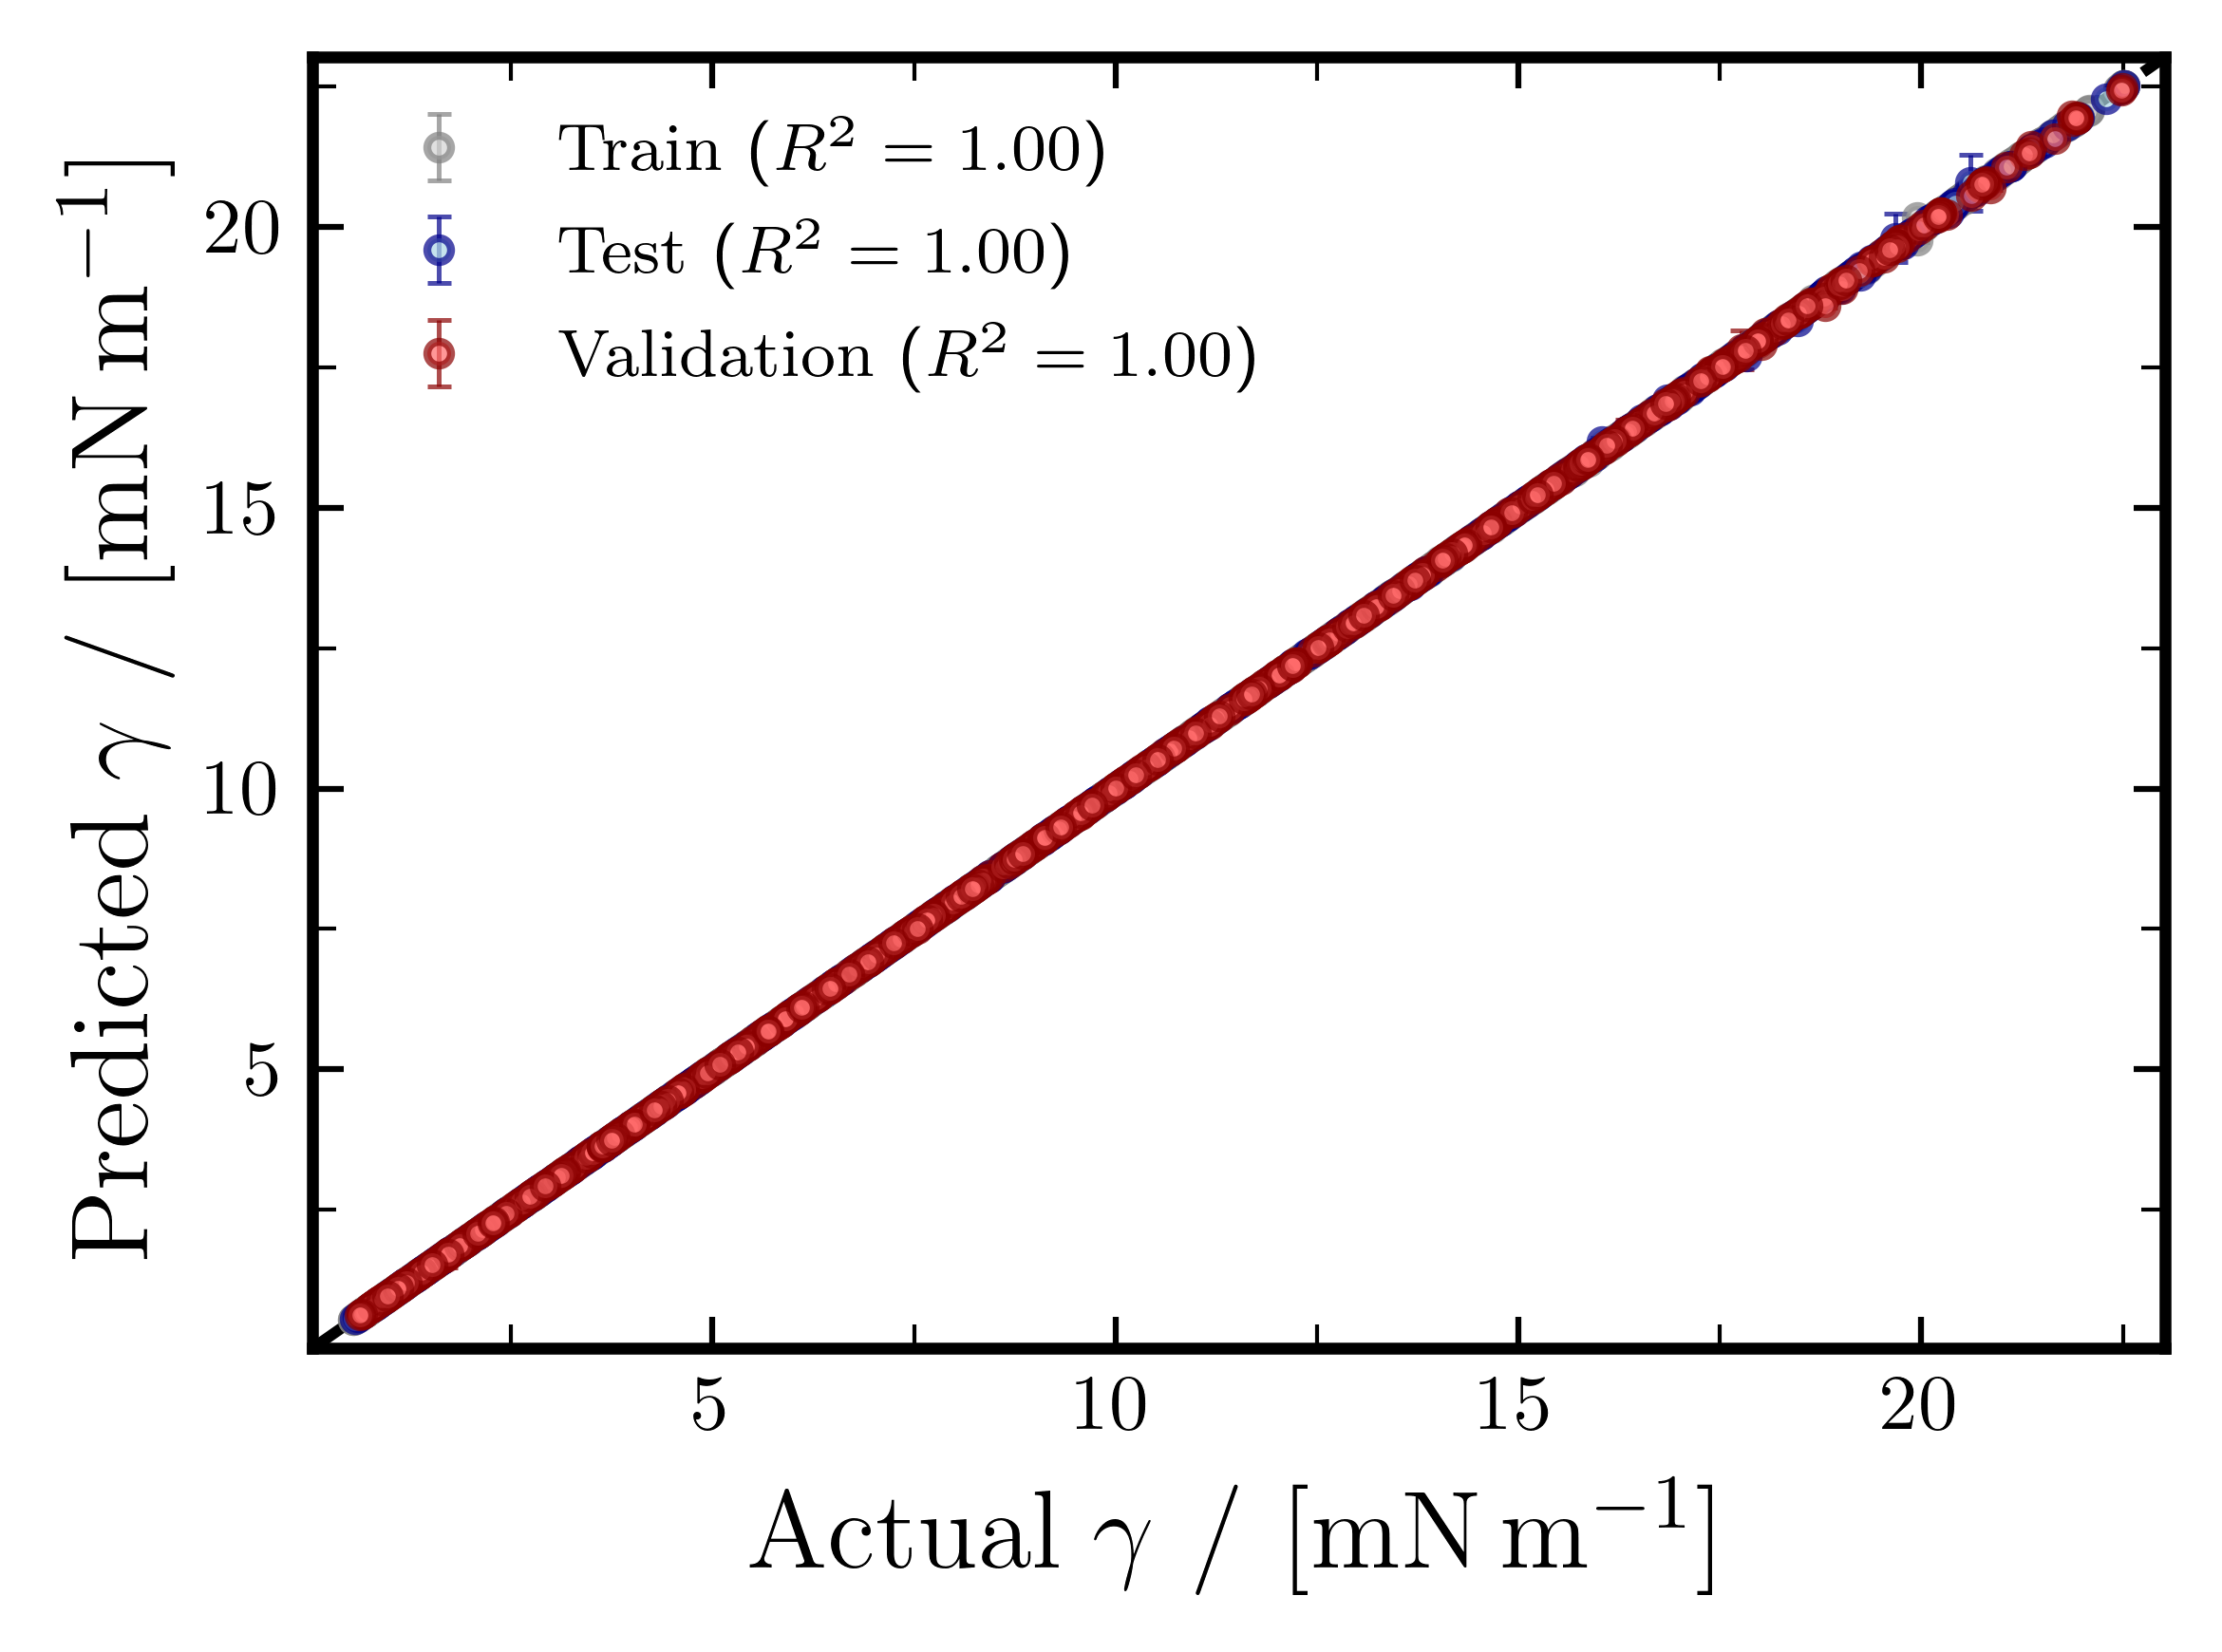

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}\\; {\\gamma}$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$\\mathrm{Predicted}\\;{\\gamma}$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [15]:
# Parity plot: gamma_cDFT (actual) vs gamma_pred (reconstructed) with ±2σ uncertainty
post.plot_reconstructed_parity(
    datasets_reconstructed={
        "train": (gamma_cDFT_train, gamma_pred_train, y_train_std),
        "test":  (gamma_cDFT_test,  gamma_pred_test,  y_test_std),
        "val":   (gamma_cDFT_val,   gamma_pred_val,   y_val_std),
    },
    n_sigma=2.0,
    model_name="GPR",
    save_path="GPR_gamma_reconstructed_parity",
    folder=OUTPUT_FOLDER,
)

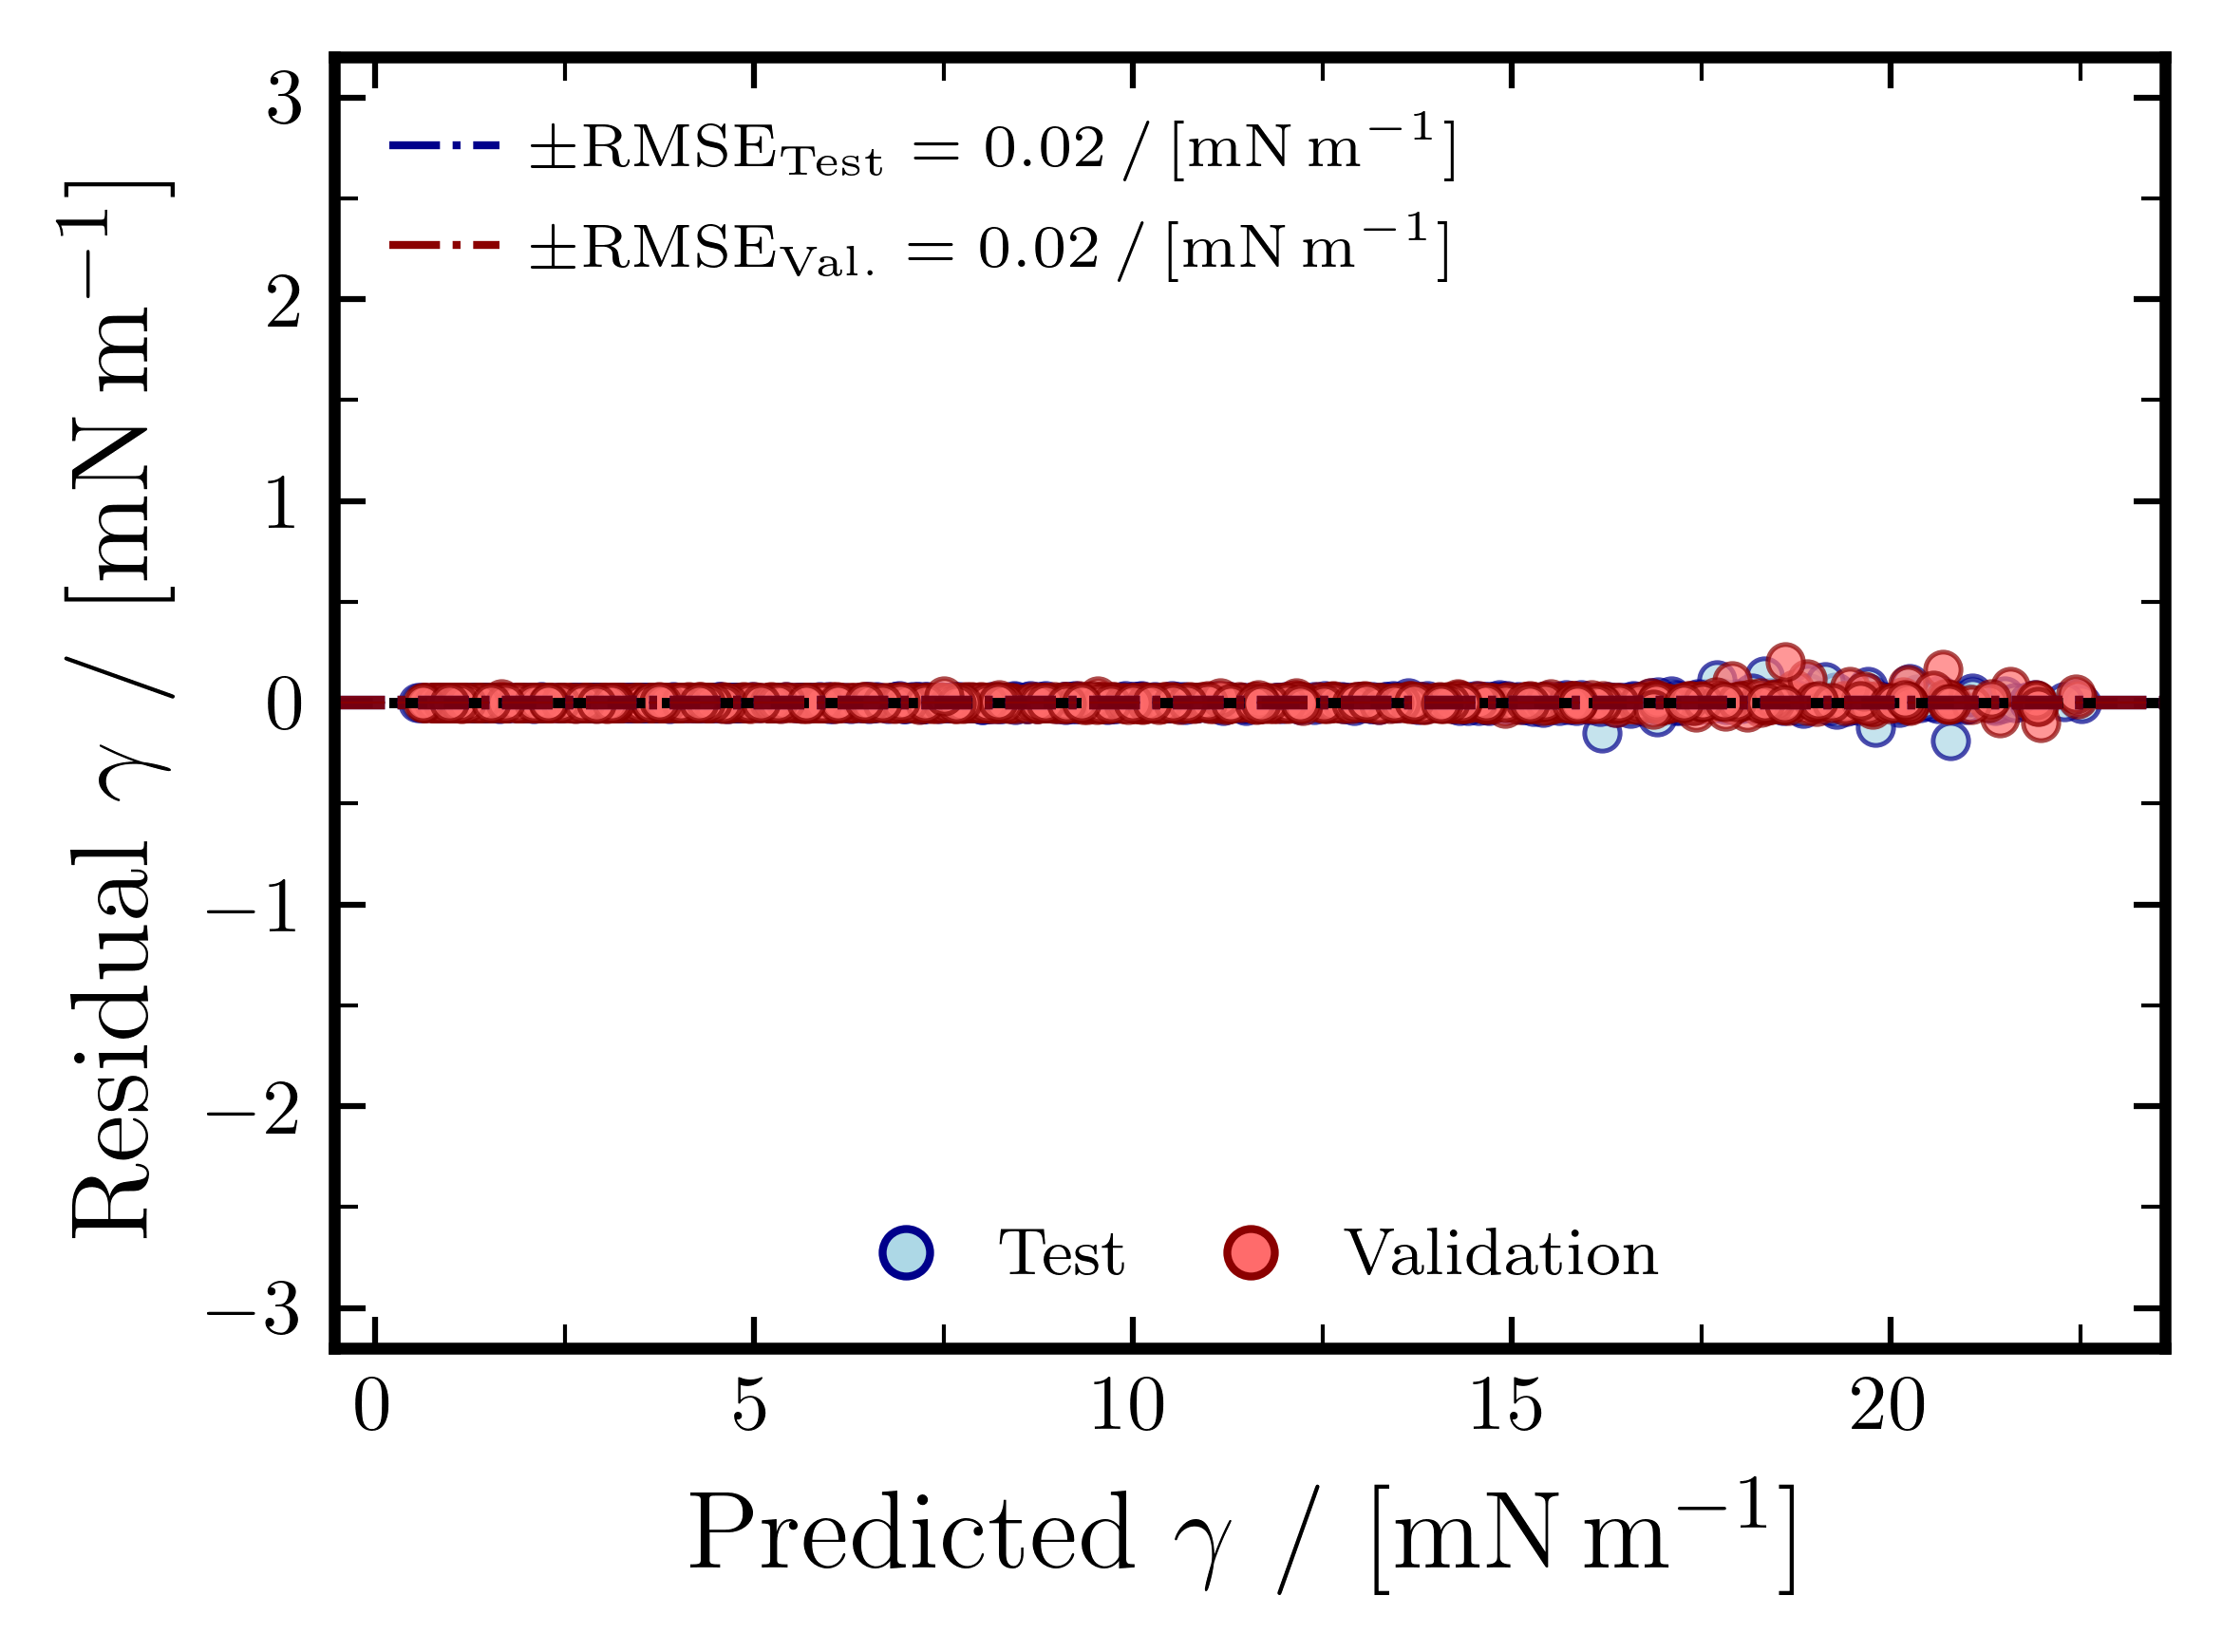

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$', ylabel='$\\mathrm{Residual}$ $\\gamma$ / $[\\mathrm{mN\\,m^{-1}}]$'>)

In [16]:
# Residuals vs Predicted: reconstructed γ_cDFT (actual γ_cDFT vs reconstructed γ_pred)
post_gamma = MLPostprocessing(
    y_true   = gamma_cDFT_test,
    y_pred   = gamma_pred_test,
    target   = "gamma",
    datasets = {
        "train": (gamma_cDFT_train, gamma_pred_train),
        "test":  (gamma_cDFT_test,  gamma_pred_test),
        "val":   (gamma_cDFT_val,   gamma_pred_val),
    },
)
post_gamma.plot_residual_vs_predicted(
    save_path = "GPR_gamma_reconstructed_residual_vs_predicted",
    folder    = OUTPUT_FOLDER,
    y_range   = (-3.2, 3.2),
)

In [17]:
post.print_summary()

MODEL PERFORMANCE SUMMARY - DELTA_GAMMA
Samples:        750
R² Score:       0.999297
RMSE:           0.015839
MAE:            0.005643
Mean Residual:  0.000897
Std Residual:   0.015814

FEATURE IMPORTANCES:
------------------------------------------------------------
  z_hydrogen                |  29.35% | ██████████████
  P                         |  27.40% | █████████████
  T                         |  20.87% | ██████████
  z_carbon_dioxide          |  12.23% | ██████
  z_methane                 |   5.13% | ██
  z_nitrogen                |   1.79% | 
  z_hydrogen_sulfide        |   1.71% | 
  z_carbon_monoxide         |   1.05% | 
  z_argon                   |   0.47% | 
